# Deriving a water level record from GNSS-IR at Grise Fiord

This documents the processing chain that turns raw GNSS receiver logs from the PRECIPICE sensor at
**Ausuittuq (Grise Fiord), Nunavut** into a sea level record.

## How GNSS-IR works

A GNSS antenna receives each satellite’s signal twice: once directly from the satellite and once after it reflects off the sea surface. The direct and reflected signals interfere with each other at the antenna, causing the recorded signal strength to oscillate as the satellite rises or sets. The oscillation is easiest to detect at low elevation angles, which is why the technique uses a narrow elevation window (see Section 1). The frequency of these oscillations is directly proportional to the vertical distance between the antenna and the water surface. By combining signals from multiple satellites, we can use these oscillations to estimate changes in water level over time.

This method is especially well suited to the Arctic, where harsh conditions and remoteness make traditional tide gauge records sparse.

## The software and where it comes from

Processing was done with **[gnssir-rt-dev](https://github.com/Precipice-Sensors/gnssir-rt-dev)**, Dave Purnell’s GNSS-IR software developed for the custom PRECIPICE sensors that he and colleagues developed. We use this version because the Grise Fiord site uses one of these instruments. Dave’s more general implementation of the same approach is available in **[gnssir-rt](https://github.com/purnelldj/gnssir-rt)**.

The broader reference for the technique is Kristine Larson’s **[gnssrefl](https://github.com/kristinemlarson/gnssrefl)**, a comprehensive open-source GNSS-IR toolkit with extensive documentation at **[gnssrefl.readthedocs.io](https://gnssrefl.readthedocs.io/en/latest/)**. If you want more detail on any of the steps below, that is a good place to start.

This notebook does not reimplement the software. Instead, it walks through the same processing steps using a subset of the full dataset, demonstrating the method one step at a time.

## What you need to run this

An **arc** is a single continuous rising or setting pass of one satellite across the elevation window, recorded by one antenna. One arc produces one reflector-height estimate. At this site, a single day produces a few hundred arcs across all satellites and antennas.

A `sample_data/` folder comes with the repo and is about 5 MB. It contains one arc, the full day of data from the satellite that arc came from, three days of processed arcs and their corresponding sea-level output, two cropped Sentinel-2 scenes, and the v5 configuration file containing the parameter values settled on after testing. Sections 2 through 7 can be run using this data alone.

This is a small subset of the full dataset, sized to demonstrate the method rather than reproduce the full analysis. It contains one arc out of a few hundred produced per day and three days from a record spanning August 2024 to October 2025, collected across four antennas. The numbers produced by the notebook illustrate the processing steps and should not be interpreted as the results of the full analysis.

The raw receiver files are not included. These are the **NMEA** logs written directly by the instrument (NMEA 0183 is the plain-text serial format used by GPS hardware since the 1980s; see Section 3). A single day of raw logs is about 30 MB, with another 76 MB generated when signal-strength data are extracted. The first stage of Section 3 is therefore described rather than executed.

## Processing steps

| Step | Stage | Module and functions | Output |
|---|---|---|---|
| 1 | NMEA to SNR | `nmea.py`: `nmea2snr`, `nmeasort`, `read_gsv` | `.snr` files: satellite ID, elevation, azimuth, time, signal strength, antenna |
| 2 | Split into arcs | `snr.py`: `SNR.qc`, `find_arcinds`, `to_arcs` | one rising or setting pass per arc |
| 3 | Arc to reflector height | `snr2arc.py`: `snr2arc`, `lsp` | one height in metres per arc |
| 4 | A day of arcs | `arcs.py`: `arcsqc`, `collect_arcs` | hundreds of height estimates per day |
| 5 | Arcs to sea level | `arcs2spline.py`, `spline.py`, `tropd.py` | continuous water level series |

---
## 0. Setup

Paths are relative to the notebook location; no machine-specific paths are used.

`pyproj` requires access to its PROJ database for coordinate conversions. On some setups, the database cannot be found, causing transforms to fail with `Internal Proj Error: proj_create: no database context specified`. The cell below first tests a coordinate transform and only overrides the database path if that test fails, so it does nothing on a working installation.

In [1]:
import os, sys, json, warnings
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Rectangle, Wedge, Patch
from matplotlib.lines import Line2D

from astropy.timeseries import LombScargle

warnings.filterwarnings('ignore', message='pyproj unable to set')   # matches both wordings

import pyproj
def _fix_proj_datadir():
    for cand in (None, Path(sys.prefix) / 'share' / 'proj',
                 Path(pyproj.__file__).parent / 'proj_dir' / 'share' / 'proj'):
        if cand is not None:
            if not (Path(cand) / 'proj.db').exists():
                continue
            pyproj.datadir.set_data_dir(str(cand))
        try:
            pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:32617', always_xy=True).transform(-83, 76)
            return pyproj.datadir.get_data_dir()
        except Exception:
            continue
    raise RuntimeError('pyproj cannot find a working PROJ database')
PROJ_DIR = _fix_proj_datadir()
from pyproj import Transformer

_here = Path.cwd().resolve()
PROJECT_ROOT = _here.parent if _here.name == 'notebooks' else _here
SAMPLE = PROJECT_ROOT / 'sample_data'
FIGS   = PROJECT_ROOT / 'figures'
FIGS.mkdir(exist_ok=True)

# ── site and v5 configuration ──
ANT_LAT, ANT_LON = 76.417075, -82.896439
LAMBDA  = 0.1903                 # GPS L1 carrier wavelength, metres
AZILIMS = (180, 250)             # ocean-facing azimuths, degrees from true north
ELVLIMS = (5, 25)                # satellite elevation window, degrees
RHLIMS  = (9, 13)                # plausible antenna-to-water distance, metres
AHGT    = {0: 0.185, 1: 0.185, 2: 0.095, 3: 0.095}   # per-antenna offsets, metres

ANT_COLORS = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green', 3: 'tab:red'}
GPS_EPOCH  = datetime(1980, 1, 6)

def gps_to_dt(t):
    "GPS seconds to UTC datetime. Leap seconds are not applied; the offset is constant and small here."
    return GPS_EPOCH + timedelta(seconds=int(t))

print(f'python  : {sys.version.split()[0]}')
print(f'proj db : {"ok" if Path(PROJ_DIR, "proj.db").exists() else "MISSING"}')
print(f'sample  : {"found" if SAMPLE.exists() else "MISSING - see the repo README"}')
print(f'v5      : azi {AZILIMS}, elv {ELVLIMS}, rh {RHLIMS}')

python  : 3.11.0
proj db : ok
sample  : found
v5      : azi (180, 250), elv (5, 25), rh (9, 13)


---
## 1. The geometry

The quantity of interest is the **reflector height**, `RH`, the vertical distance from the antenna down to the reflecting surface. At Grise Fiord it averages about 11 m and varies from roughly 9 to 13 m with the tide, which is what the `rhlims` search range is set to. When the tide comes in, the water rises and `RH` gets smaller, so changes in water level are reflected by opposite changes in `RH`.

Where the reflection comes from depends on the satellite’s elevation angle. A satellite low on the horizon reflects off a point far out from shore, while a higher satellite reflects off a point much closer in. For an `RH` of 11 m, the specular point, where the angle of incidence equals the angle of reflection, ranges from roughly 125 m offshore at 5° elevation to 24 m offshore at 25°. The elevation window therefore determines which patch of water is being measured (see the figure below).

This is also why the technique uses low elevation angles. Near the horizon, the water provides a strong reflection and the reflection point lies well out on the water surface, making the interference easier to detect in the recorded signal. At higher elevation angles, the reflected signal weakens and the reflection point moves toward shore, eventually falling on land rather than water at a coastal site like this one. Hence the `elvlims` of 5° to 25°, and hence the short arcs: each satellite passes through this elevation window only briefly.


### Why the frequency carries the height

The reflected signal travels an extra distance of $2\,RH\sin\varepsilon$ before reaching the antenna, where
$\varepsilon$ is the satellite elevation angle. That extra path shifts its phase relative to the direct
signal, so the two add constructively or destructively depending on where $\varepsilon$ is. The detrended
signal-to-noise ratio therefore oscillates as

$$\delta\mathrm{SNR}(\varepsilon)\;\propto\;\cos\!\left(\frac{4\pi\,RH}{\lambda}\sin\varepsilon+\phi\right)
\;=\;\cos\!\left(2\pi f\sin\varepsilon+\phi\right),\qquad\boxed{\,f=\frac{2\,RH}{\lambda}\,}$$

with $\lambda$ the carrier wavelength (e.g. GPS L1, 0.1903 m) and $\phi$ a phase offset that depends on the
surface.

The important part is the change of variable. Written against $\sin\varepsilon$ rather than against
$\varepsilon$ or against time, the frequency $f$ is **constant** for a fixed reflector height, so one arc
produces one well-defined spectral peak. At $RH$ of 11 m that works out to about 116 cycles per unit of
$\sin\varepsilon$. Measure $f$, and $RH = f\lambda/2$ follows.

The schematic below shows both elevation extremes, with an inset of what the antenna records.

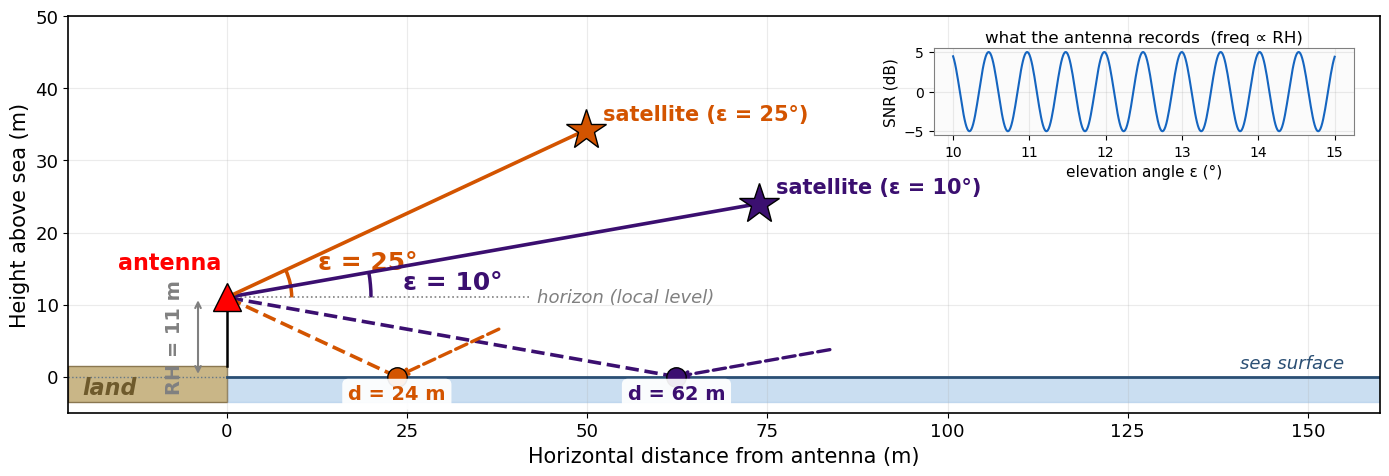

In [2]:
# ── 1. Geometry schematic ──
RH_SCHEM = 11
EPS_LO, EPS_HI = 10, 25
LAND_TOP = 1.5
COLORS = {EPS_LO: '#3b0f70', EPS_HI: '#d35400'}

FS_LABEL, FS_VALUE, FS_AXES, FS_TICK, FS_NOTE, FS_SAT, FS_EPS = 16, 14, 15, 13, 13, 15, 18

fig, ax = plt.subplots(figsize=(14, 5.5))

# Sea
ax.fill_between([0, 200], -3.5, 0, color='#a8c8e8', alpha=0.6)
ax.plot([0, 200], [0, 0], color='#2b4f74', lw=2.0, zorder=2)
ax.plot([-22, 0], [0, 0], ':', color='#2b4f74', lw=1.0, alpha=0.6, zorder=2)
ax.text(155, 0.6, 'sea surface', color='#2b4f74', fontsize=FS_NOTE,
        ha='right', va='bottom', style='italic', zorder=5)

# Land
ax.add_patch(Rectangle((-22, -3.5), 22, LAND_TOP + 3.5,
                       facecolor='#c9b687', edgecolor='#8a7750', lw=1.0, zorder=1))
ax.text(-20, -1.5, 'land', color='#6e5a2c', fontsize=FS_LABEL,
        fontweight='bold', va='center', ha='left', style='italic')

# Antenna support
ax.plot([0, 0], [LAND_TOP, RH_SCHEM], 'k-', lw=1.8, zorder=3)
ax.plot(0, RH_SCHEM, marker='^', markersize=20, color='red', mec='black', zorder=10)
ax.annotate('antenna', (0, RH_SCHEM), xytext=(-4, 20), textcoords='offset points',
            fontsize=FS_LABEL, fontweight='bold', color='red', ha='right')

# RH arrow
ax.annotate('', xy=(-4, 0), xytext=(-4, RH_SCHEM),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5), zorder=5)
ax.text(-6, RH_SCHEM/2, f'RH = {RH_SCHEM} m', rotation=90, ha='right', va='center',
        fontsize=FS_VALUE, color='gray', fontweight='bold', zorder=5)

# Horizon
ax.plot([0, 42], [RH_SCHEM, RH_SCHEM], ':', color='gray', lw=1.2)
ax.text(43, RH_SCHEM, 'horizon (local level)', color='gray', fontsize=FS_NOTE,
        ha='left', va='center', style='italic')

SAT_DIST = {EPS_LO: 75, EPS_HI: 55}
INCOMING = {EPS_LO: 22, EPS_HI: 16}

for eps_deg in (EPS_LO, EPS_HI):
    e   = np.deg2rad(eps_deg)
    col = COLORS[eps_deg]
    d   = RH_SCHEM / np.tan(e)

    sat_x = SAT_DIST[eps_deg] * np.cos(e)
    sat_y = RH_SCHEM + SAT_DIST[eps_deg] * np.sin(e)
    ax.plot([0, sat_x], [RH_SCHEM, sat_y], '-', color=col, lw=2.6, zorder=5)

    par_x = d + INCOMING[eps_deg] * np.cos(e)
    par_y =     INCOMING[eps_deg] * np.sin(e)
    ax.annotate('', xy=(d, 0), xytext=(par_x, par_y),
                arrowprops=dict(arrowstyle='->', color=col, lw=2.4, linestyle='--'), zorder=5)
    ax.plot([d, 0], [0, RH_SCHEM], '--', color=col, lw=2.6, zorder=5)

    ax.plot(d, 0, 'o', color=col, markersize=14, mec='black', zorder=6)
    ax.text(d, -1.1, f'd = {d:.0f} m', ha='center', va='top', color=col,
            fontsize=FS_VALUE, fontweight='bold',
            bbox=dict(fc='white', ec='none', alpha=0.92, boxstyle='round,pad=0.3'), zorder=7)

    ax.plot(sat_x, sat_y, marker='*', markersize=30, color=col, mec='black', zorder=6)
    ax.annotate(f'satellite (ε = {eps_deg}°)', (sat_x, sat_y), xytext=(12, 7),
                textcoords='offset points', fontsize=FS_SAT, color=col, fontweight='bold')

    r_arc = 9 if eps_deg == EPS_HI else 20
    ax.add_patch(Arc((0, RH_SCHEM), 2*r_arc, 2*r_arc, angle=0, theta1=0, theta2=eps_deg,
                     color=col, lw=2.5))
    lbl_r = r_arc + 4.5
    lbl_a = e * (0.85 if eps_deg == EPS_HI else 0.5)
    ax.text(lbl_r * np.cos(lbl_a), RH_SCHEM + lbl_r * np.sin(lbl_a),
            f'ε = {eps_deg}°', color=col, fontsize=FS_EPS, fontweight='bold',
            ha='left', va='center')

# Inset: what the antenna records. Beat frequency in sin(e) is 2*RH/lambda.
ax_in = ax.inset_axes([0.66, 0.70, 0.32, 0.22])
eps_in = np.linspace(10, 15, 400)
snr_in = 5 * np.cos(2 * np.pi * (2 * RH_SCHEM / LAMBDA) * np.sin(np.deg2rad(eps_in)))
ax_in.plot(eps_in, snr_in, color='#1565c0', lw=1.5)
ax_in.set_xlabel('elevation angle ε (°)', fontsize=11)
ax_in.set_ylabel('SNR (dB)', fontsize=11)
ax_in.tick_params(labelsize=10)
ax_in.set_title('what the antenna records  (freq ∝ RH)', fontsize=12, pad=4)
ax_in.grid(True, alpha=0.25)
ax_in.set_facecolor('#fbfbfb')
for s in ax_in.spines.values():
    s.set_edgecolor('gray'); s.set_linewidth(0.8)

ax.set_xlim(-22, 160)
ax.set_ylim(-5, 50)
ax.set_aspect('equal')
ax.set_xlabel('Horizontal distance from antenna (m)', fontsize=FS_AXES)
ax.set_ylabel('Height above sea (m)', fontsize=FS_AXES)
ax.tick_params(axis='both', labelsize=FS_TICK)
ax.grid(True, alpha=0.25)
for sp in ax.spines.values():
    sp.set_zorder(100); sp.set_linewidth(1.2)

plt.tight_layout()
fig.savefig(FIGS / 'gnssir_geometry_schematic.pdf', bbox_inches='tight',
            metadata={'CreationDate': None})
fig.savefig(FIGS / 'gnssir_geometry_schematic.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 2. Running the software

`gnssir-rt-dev` is a command-line interface (CLI) driven by a single YAML configuration file. Install it, then run the three tasks in order:

```bash
git clone https://github.com/Precipice-Sensors/gnssir-rt-dev.git
cd gnssir-rt-dev
python -m venv .venv && source .venv/bin/activate
python -m pip install -e .

gnssir -c configs/precipice_v5.yaml -t nmea2snr        # step 1
gnssir -c configs/precipice_v5.yaml -t snr2arcs        # steps 2-4
gnssir -c configs/precipice_v5.yaml -t arcs2splines    # step 5
```

Each task reads the directories the previous one wrote, so the config is the only thing that changes between
runs. **v5 is the fifth pass**, each one tightening the azimuth and height
windows until the retrieval was drawing on the right surface. v1 to v4 are the same file with wider windows.

Note that `gnssir-rt-dev` may still be private. If you cannot reach it, `gnssir-rt` is public and follows
the same general steps.

### What the v5 settings do

| Setting     | v5 value        | What it does                                                                                                                                                                                                                |
| ----------- | --------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `azilims`   | `[180, 250]`    | Keeps only reflections arriving from S to WSW, the direction of open water. Section 5 shows why.                                                                                                                      |
| `elvlims`   | `[5, 25]`       | Satellite elevation window. Together with `rhlims` this sets the Fresnel zone geometry, and so where on the surface the reflection comes from. Section 5 maps that footprint.                                             |
| `rhlims`    | `[9, 13]`       | Search range for the antenna-to-water distance. Restricts the spectral peak search to physically plausible heights.                                                                                                   |
| `ahgt_dict` | 0.185 / 0.095 m | Per-antenna vertical offsets, added back after the fit so that all four antennas share a common datum.                                                                                                                |
| `nodelen`   | 14400 s         | Spline node spacing (4 hours). Long enough to smooth arc noise, but short enough to follow a semi-diurnal tide.                                                                                                       |
| `qcparams`  | relaxed         | `clrlim` and `ptnlim` are set to 0, retaining low-quality arcs that stricter settings would drop. `splinedifflim` and `maxerrlim` are both set to 1 m, still removing large outliers and poorly fitting spline nodes. |


Note that v5 reuses the SNR files produced by v2. Azimuth and height filtering are applied at the arc stage, rather than during NMEA parsing, so changing these windows does not require reparsing the raw logs.

`precipice_v5.yaml` contains all of the inputs needed for processing and serves as the complete record of how a run was configured. Two versions are included. `precipice_v5.yaml` is the first-month run shown below, while `precipice_v5_full.yaml` is identical except for `dt_start` and `dt_end`. The latter covers the full deployment and is the run used to produce the sea-level record presented here.

In [3]:
# ── 2. The v5 config, as it was run ──
cfg_text = (SAMPLE / 'precipice_v5.yaml').read_text()
print(cfg_text)

# PRECIPICE GNSS-IR Configuration - V5
# NOTE: published copy. basedir blanked and one comment generalised;
# all processing parameters are exactly as run.
# Changes from V4: azilims narrowed to [180, 250] (ocean-facing only),
# rhlims tightened to [9, 13] based on per-azimuth correlation analysis
# against independent in-situ water level observations.
# Reuses SNR files from v2 (azimuth/RH filtering happens at arcs stage).
# Local processing (not AWS)
aws_access: False
basedir: "/path/to/your/PRECIPICE"
dir_nmea: "raw"
dir_snr: "processed/snr_v2"
dir_arcs: "processed/arcs_v5"
dir_spline: "processed/spline_v5"

# NMEA file format: YYMMDD/HHMM.FIX
nmeafilefmt: "%y%m%d/%H%M.FIX"
nmeastep: 60

# REQUIRED PARAMS
site_name: "precipice"
arcfilefmt: "precipice_l1_%y%m%d_24h.csv"
splinecsvout: "precipice_sealevel_v5.csv"

# dates in the format YY-MM-DD HHMM
# Processing first month: Aug 21 - Sep 21, 2024
dt_start: "24-08-21 0000"
dt_end: "24-09-21 0000"

# site location (from NMEA data: ~76.42

---

## 3. From receiver logs to arcs (steps 1 and 2)

### Step 1, NMEA to SNR

The receiver writes one file per minute of **NMEA 0183**, the plain-text serial protocol used by GPS hardware since the 1980s. All four antennas write to the same file, one line at a time, so their data streams are mixed together. Each line has a non-standard `N=` prefix added by the PRECIPICE firmware that identifies which antenna it came from.

The sentences that matter are `$GPGSV`, `$GLGSV`, and `$GAGSV`, which report satellites in view for GPS, GLONASS, and Galileo, respectively. Each contains, for each satellite, its **PRN** (pseudo-random noise code, the identifier that distinguishes one satellite from another within a constellation), elevation, azimuth, and signal strength. The latter is labelled SNR in the NMEA data, but is technically carrier-to-noise density, measured in dB-Hz. In the sample day used here, values range from about 6 to 45 dB-Hz. The amplitude of variation is greatest at low elevation angles, where the interference the method relies on is strongest.

`nmea2snr` reads each one-minute file in the date range line by line. For each line, it strips the antenna prefix, takes the timestamp from the `$GNRMC` sentence, and extracts the four fields from each `*GSV` sentence. It renumbers PRNs so that the constellations do not overlap (GPS remain 1–32, GLONASS become 101–124, and Galileo 201 and above), then writes one whitespace-delimited row per satellite per epoch into hourly `.snr` files.

This step only converts the receiver output into the `.snr` format used by the processing pipeline. No GNSS-IR processing happens yet.

One important limitation is that NMEA records elevation only to the nearest degree.



### Step 2, splitting into arcs

`snr2arcs.py` reads a day of `.snr` files and cuts them into arcs, each arc being one satellite's single
rising or setting pass.

1. **Elevation interpolation** (`elvinterp.py`, `elv_interp_array`). Whole-degree elevation is too coarse,
   because the oscillation phase depends on `sin(elevation)` and one-degree steps smear the spectral peak.
   A cubic spline is fitted to elevation versus time, with nodes spaced about 30 minutes apart, to recover
   fractional elevation values between the whole-degree steps.
2. **`SNR.qc`** applies the config cuts: chosen antennas, `elvlims`, `azilims`.
3. **`SNR.remove_duplicates`**. This receiver writes each observation twice. Without removing the copies, the elevation difference between duplicate rows is zero. This causes the sign test in step 5 to incorrectly detect direction changes, breaking every pass into fragments that are too short to keep and resulting in zero arcs.
4. **`SNR.sort`** by antenna, then PRN, then time.
5. **`SNR.find_arcinds`** marks a break wherever the antenna changes, the PRN changes, there is a gap longer
   than 5 minutes, or **the elevation rate flips sign**, meaning the satellite stopped rising and began
   setting. Runs of at least 20 points between breaks become arcs.

Splitting on the direction change is the important part. Within one pass the satellite only rises or only
sets, so the interference appears as a single clean frequency. A combined pass would cover the same
elevation range twice, overlaying the two halves at different phases and smearing the spectral peak.

The figure below shows one satellite, PRN 3 on antenna 0, over 2024-08-22. It rises above the horizon and
sets again three separate times that day. One of those passes falls inside the elevation window and the ocean azimuth window, and that is
the arc carried forward.

In the right-hand panel, the recorded signal strength does not fall off smoothly as the satellite sets. It
rises and falls repeatedly on the way down. That regular rise and fall is the interference between the
direct and reflected signals, and it is the entire measurement. Everything in section 4 is about extracting
its frequency.

PRN 3, antenna 0, 287 points, elevation 5.0 to 25.0 deg (setting)


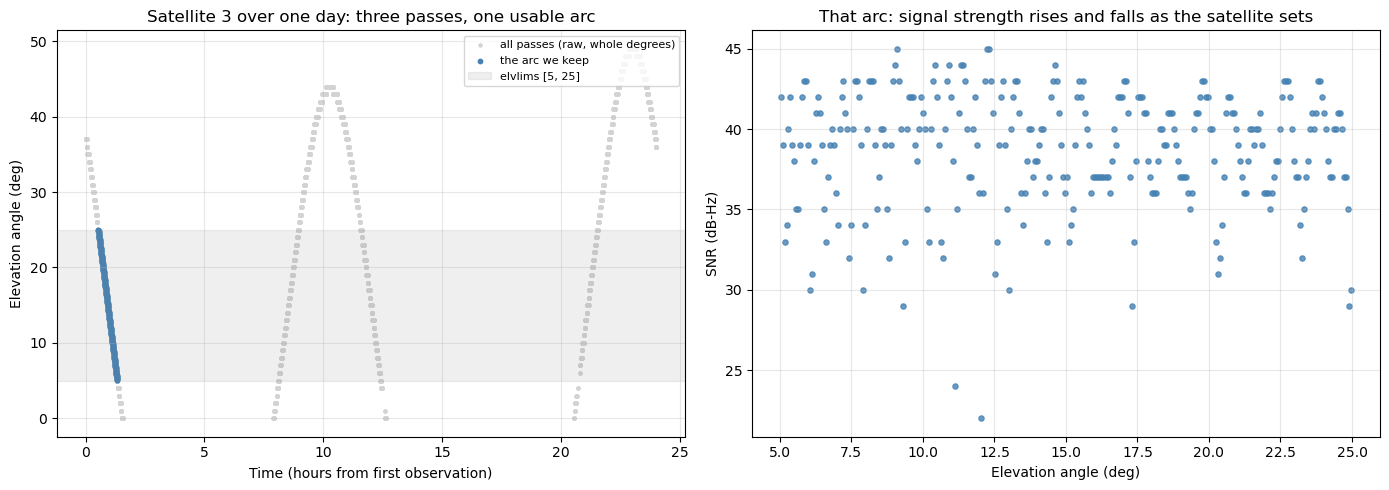

In [4]:
# ── 3. One satellite's day, and the arc kept from it ──
sat_day = pd.read_csv(SAMPLE / 'one_satellite_day_240822.csv')
arc     = pd.read_csv(SAMPLE / 'one_arc_240822.csv')

prn, aid = int(arc['prn'].iloc[0]), int(arc['ant'].iloc[0])
direction = 'rising' if arc['elv'].iloc[-1] > arc['elv'].iloc[0] else 'setting'
print(f'PRN {prn}, antenna {aid}, {len(arc)} points, '
      f'elevation {arc["elv"].min():.1f} to {arc["elv"].max():.1f} deg ({direction})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

t0 = sat_day['gps_time'].min()
ax1.scatter((sat_day['gps_time'] - t0) / 3600, sat_day['elv'],
            s=5, c='lightgray', label='all passes (raw, whole degrees)')
ax1.scatter((arc['gps_time'] - t0) / 3600, arc['elv'],
            s=10, c='steelblue', label='the arc we keep')
ax1.axhspan(*ELVLIMS, color='gray', alpha=0.12, label=f'elvlims {list(ELVLIMS)}')
ax1.set_xlabel('Time (hours from first observation)')
ax1.set_ylabel('Elevation angle (deg)')
ax1.set_title(f'Satellite {prn} over one day: three passes, one usable arc')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.scatter(arc['elv'], arc['snr'], s=14, c='steelblue', alpha=0.8)
ax2.set_xlabel('Elevation angle (deg)')
ax2.set_ylabel('SNR (dB-Hz)')
ax2.set_title(f'That arc: signal strength rises and falls as the satellite {direction[:-4]}s')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGS / 'gnssir_step2_one_arc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. One arc to one height (step 3)

`snr2arc.py`'s `snr2arc` does four things to the arc above.

1. **Change variable to `sin(elevation)`.** The oscillation has a constant frequency in this coordinate, not
   in elevation or in time.
2. **Linearise out of decibels**, `snr = 10**(snr/20)`, since SNR is logarithmic and the interference adds
   in linear power.
3. **Detrend.** Fit a degree-2 polynomial and subtract it. That removes the slow hump from the antenna's
   gain pattern, leaving only the oscillation.
4. **Find the frequency.** `lsp` runs a Lomb-Scargle periodogram over trial reflector heights across
   `rhlims`, at 1 mm spacing. Lomb-Scargle rather than an FFT because the samples are unevenly spaced in
   `sin(elevation)`. Each trial height maps to a frequency by `f = 2·RH/λ`. The tallest peak is the arc's
   reflector height.

The same periodogram yields the quality metrics stored with each arc: `ptn` (peak over mean power), `pr`
(tallest peak over second tallest), `clr` (clarity), and `tanededt`, which is `tan(mean elevation)` divided
by the elevation rate and gets used for the moving-surface correction in step 5.

One arc gives one reflector height, the vertical distance from the antenna to the water surface at that point in time.

**Detrending does not discard data.** The fitted polynomial is subtracted from every observation, so all 287 points remain in the arc with new values. Panel b looks sparser because it is zoomed in. At an RH of about 12 m, the oscillation completes roughly 40 cycles across the arc, with observations every 10 seconds. That gives only about 7 samples per cycle, so the signal looks noisy when the points are connected. The shaded strip in panel a shows the portion plotted in panel b. The periodogram in panel c uses the full arc.

reflector height for this arc: 12.102 m
water surface 12.10 m below the antenna phase centre


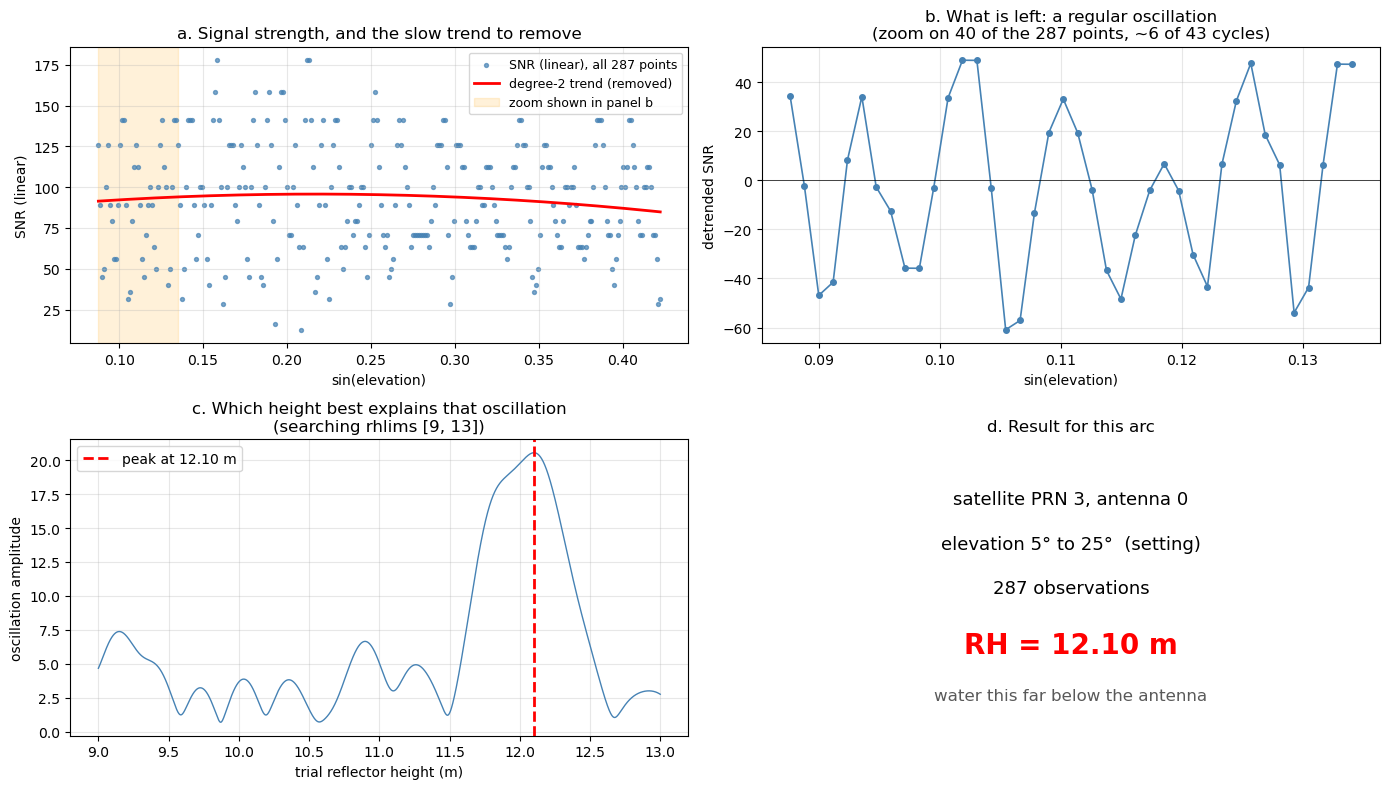

In [5]:
# ── 4. Arc to reflector height ──
elv     = arc['elv'].values.astype(float)
snr_raw = arc['snr'].values.astype(float)

sinelv   = np.sin(np.radians(elv))                 # 1. constant-frequency coordinate
snr_lin  = 10 ** (snr_raw / 20)                    # 2. out of decibels
trend    = np.poly1d(np.polyfit(sinelv, snr_lin, 2))(sinelv)   # 3. antenna gain shape
snr_dt   = snr_lin - trend                                     #    the oscillation on its own

# 4. Lomb-Scargle across trial reflector heights. f = 2*RH/lambda.
rh_grid = np.arange(RHLIMS[0], RHLIMS[1] + 1e-9, 0.001)        # 1 mm spacing
freqs   = 2 * rh_grid / LAMBDA
pgram   = LombScargle(sinelv, snr_dt, normalization='psd').power(freqs)
pgram   = 2 * np.sqrt(np.abs(pgram) / len(sinelv))   # -> amplitude of best-fit sinusoid
rh_est  = rh_grid[np.argmax(pgram)]

print(f'reflector height for this arc: {rh_est:.3f} m')
print(f'water surface {rh_est:.2f} m below the antenna phase centre')

order = np.argsort(sinelv)

# Panel b zooms in, since the whole arc holds ~40 cycles in 287 samples and reads as noise
# drawn end to end. Work out that window first so panel a can show where it sits.
cycles_per_unit = 2 * rh_est / LAMBDA
n_cycles = cycles_per_unit * (sinelv.max() - sinelv.min())
zlo = sinelv.min()
zhi = zlo + 6 / cycles_per_unit
zm  = (sinelv >= zlo) & (sinelv <= zhi)
zo  = np.argsort(sinelv[zm])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].scatter(sinelv, snr_lin, s=8, c='steelblue', alpha=0.7,
                   label=f'SNR (linear), all {len(sinelv)} points')
axes[0, 0].plot(sinelv[order], trend[order], 'r-', lw=2, label='degree-2 trend (removed)')
axes[0, 0].axvspan(zlo, zhi, color='orange', alpha=0.15, zorder=0, label='zoom shown in panel b')
axes[0, 0].set_xlabel('sin(elevation)'); axes[0, 0].set_ylabel('SNR (linear)')
axes[0, 0].set_title('a. Signal strength, and the slow trend to remove')
axes[0, 0].legend(fontsize=9); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(sinelv[zm][zo], snr_dt[zm][zo], '-o', color='steelblue', lw=1.2, ms=4)
axes[0, 1].axhline(0, color='k', lw=0.5)
axes[0, 1].set_xlabel('sin(elevation)'); axes[0, 1].set_ylabel('detrended SNR')
axes[0, 1].set_title(f'b. What is left: a regular oscillation\n'
                     f'(zoom on {int(zm.sum())} of the {len(sinelv)} points, '
                     f'~6 of {n_cycles:.0f} cycles)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(rh_grid, pgram, 'steelblue', lw=1)
axes[1, 0].axvline(rh_est, color='red', ls='--', lw=2, label=f'peak at {rh_est:.2f} m')
axes[1, 0].set_xlabel('trial reflector height (m)')
axes[1, 0].set_ylabel('oscillation amplitude')
axes[1, 0].set_title(f'c. Which height best explains that oscillation\n(searching rhlims {list(RHLIMS)})')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

ax = axes[1, 1]; ax.axis('off')
ax.set_title('d. Result for this arc')
for y, txt, kw in [
    (0.78, f'satellite PRN {prn}, antenna {aid}', dict(fontsize=13)),
    (0.63, f'elevation {elv.min():.0f}° to {elv.max():.0f}°  ({direction})', dict(fontsize=13)),
    (0.48, f'{len(arc)} observations', dict(fontsize=13)),
    (0.28, f'RH = {rh_est:.2f} m', dict(fontsize=20, fontweight='bold', color='red')),
    (0.12, 'water this far below the antenna', dict(fontsize=12, color='0.35')),
]:
    ax.text(0.5, y, txt, ha='center', **kw)

plt.tight_layout()
fig.savefig(FIGS / 'gnssir_step3_arc_to_height.png', dpi=150, bbox_inches='tight')
plt.show()

### Why the search range matters

The periodogram is only searched over `rhlims`. Widening this range can reveal additional peaks, from reflections off land or nearby structures, as well as harmonics. The same arc can therefore give different height estimates depending on the search range. The correct `rhlims` is constrained by the site geometry and the expected antenna-to-water distance.

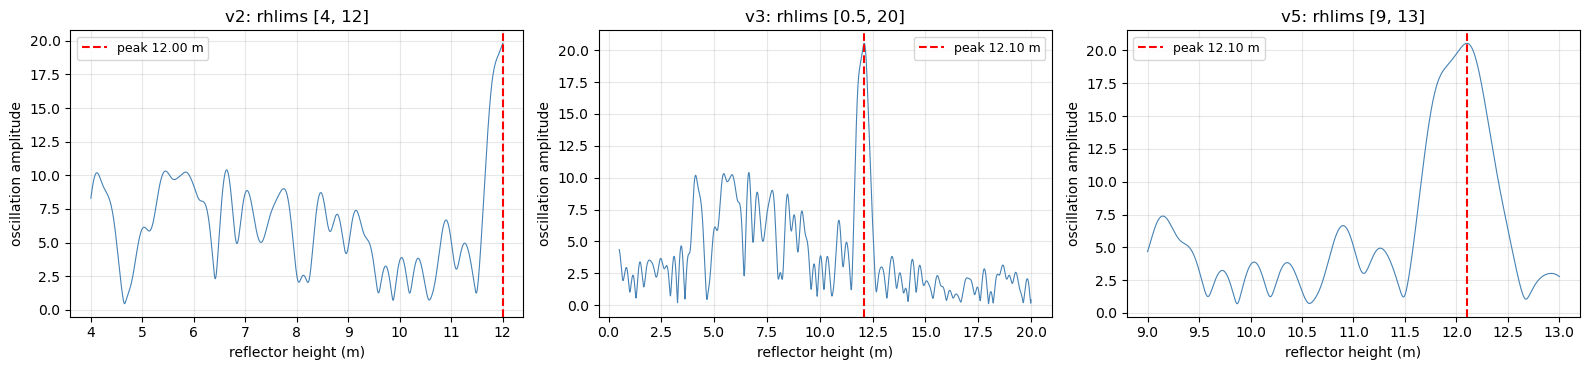

In [6]:
# ── 4b. The same arc, three search ranges ──
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, rl, label in [(axes[0], (4, 12),   'v2: rhlims [4, 12]'),
                      (axes[1], (0.5, 20), 'v3: rhlims [0.5, 20]'),
                      (axes[2], (9, 13),   'v5: rhlims [9, 13]')]:
    g  = np.arange(rl[0], rl[1] + 1e-9, 0.001)
    pg = LombScargle(sinelv, snr_dt, normalization='psd').power(2 * g / LAMBDA)
    pg = 2 * np.sqrt(np.abs(pg) / len(sinelv))
    pk = g[np.argmax(pg)]
    ax.plot(g, pg, 'steelblue', lw=0.8)
    ax.axvline(pk, color='red', ls='--', label=f'peak {pk:.2f} m')
    ax.set_xlabel('reflector height (m)'); ax.set_ylabel('oscillation amplitude')
    ax.set_title(label); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGS / 'gnssir_rhlims_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Which reflections to keep

The antenna sees the whole sky, so it also picks up reflections off land, snow, and the structure itself. Those reflections arrive from other directions and produce different apparent heights. Two configuration settings filter them out:

**Azimuth.** Only signals arriving across open water can be used to estimate sea level. Processing the same day with no azimuth filter shows the difference: in the ocean-facing sector, the heights cluster tightly around 11 m, while reflections from other directions are scattered across the search range.

**Height.** The `[9, 13]` m range matches the surveyed geometry of the site. Heights outside this range are not consistent with reflections from the sea surface.

1271 arcs on 2024-08-22 with no azimuth filter; 180 survive the v5 filters


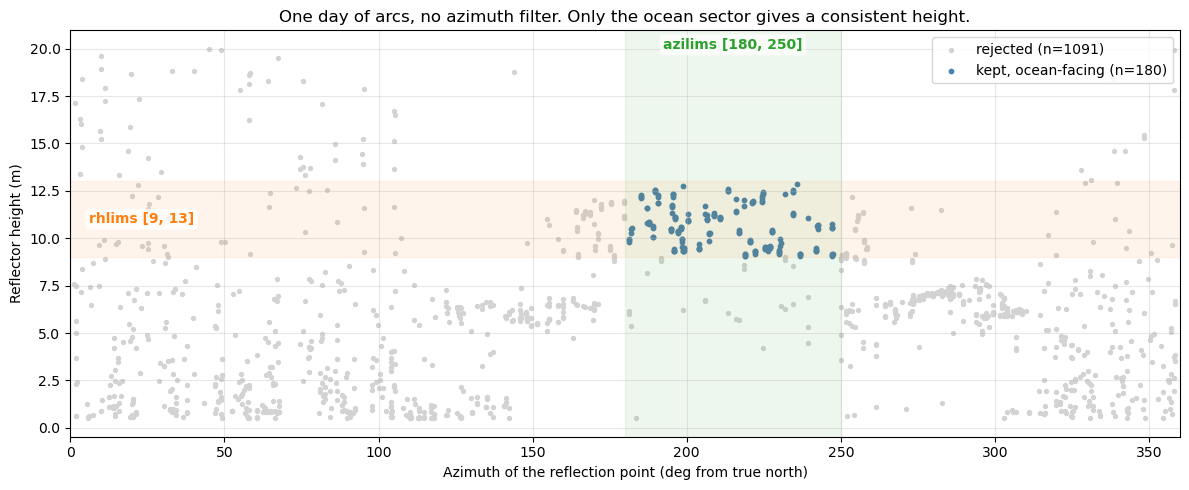

In [7]:
# ── 5a. All azimuths, one day, showing what the cuts remove ──
allazi = pd.read_csv(SAMPLE / 'arcs_allazi_240822.csv')
keep = allazi['azi'].between(*AZILIMS) & allazi['rh'].between(*RHLIMS)
print(f'{len(allazi)} arcs on 2024-08-22 with no azimuth filter; {int(keep.sum())} survive the v5 filters')

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(allazi.loc[~keep, 'azi'], allazi.loc[~keep, 'rh'], s=8, c='lightgray',
           label=f'rejected (n={int((~keep).sum())})')
ax.scatter(allazi.loc[keep, 'azi'], allazi.loc[keep, 'rh'], s=10, c='steelblue',
           label=f'kept, ocean-facing (n={int(keep.sum())})')
ax.axvspan(*AZILIMS, color='tab:green', alpha=0.08)
ax.axhspan(*RHLIMS,  color='tab:orange', alpha=0.08)
ax.set_xlabel('Azimuth of the reflection point (deg from true north)')
ax.set_ylabel('Reflector height (m)')
ax.set_title('One day of arcs, no azimuth filter. Only the ocean sector gives a consistent height.')
ax.set_xlim(0, 360); ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

# Band labels last, so they sit inside the final limits rather than the autoscaled ones.
_lab = dict(fontsize=10, fontweight='bold',
            bbox=dict(fc='white', ec='none', alpha=0.75, boxstyle='round,pad=0.25'))
ax.text(np.mean(AZILIMS), ax.get_ylim()[1] - 0.4, f'azilims {list(AZILIMS)}',
        ha='center', va='top', color='tab:green', **_lab)
ax.text(6, np.mean(RHLIMS), f'rhlims {list(RHLIMS)}',
        ha='left', va='center', color='tab:orange', **_lab)
plt.tight_layout()
fig.savefig(FIGS / 'gnssir_azimuth_masking.png', dpi=150, bbox_inches='tight')
plt.show()

### Checking the window against imagery

The azimuth window was set from that scatter, so it is worth checking independently that it points at water.

A reflection does not come from a single point. It comes from an elliptical patch of surface called the
**Fresnel zone**, which stretches out and away from the antenna as the satellite gets lower. Evaluating it
at the corners of the v5 windows (the `fresnel` function below) gives the area the instrument is actually
sensing: a wedge running from about 15 m to about 210 m out from shore, across the ocean-facing azimuths.
Drawing that on Sentinel-2 imagery shows which surface the measurement comes from.

Two scenes are included, cropped to 12 km around the antenna: April with sea ice, and August with open water.
In August the wedge covers open channel water, the case v5 was tuned for. In April it covers ice, so the
retrieval returns the ice surface instead of sea level.

Imagery: Copernicus Sentinel-2, processed by ESA.

sensing footprint: 15 m to 210 m from the antenna, azimuth 180-250 deg


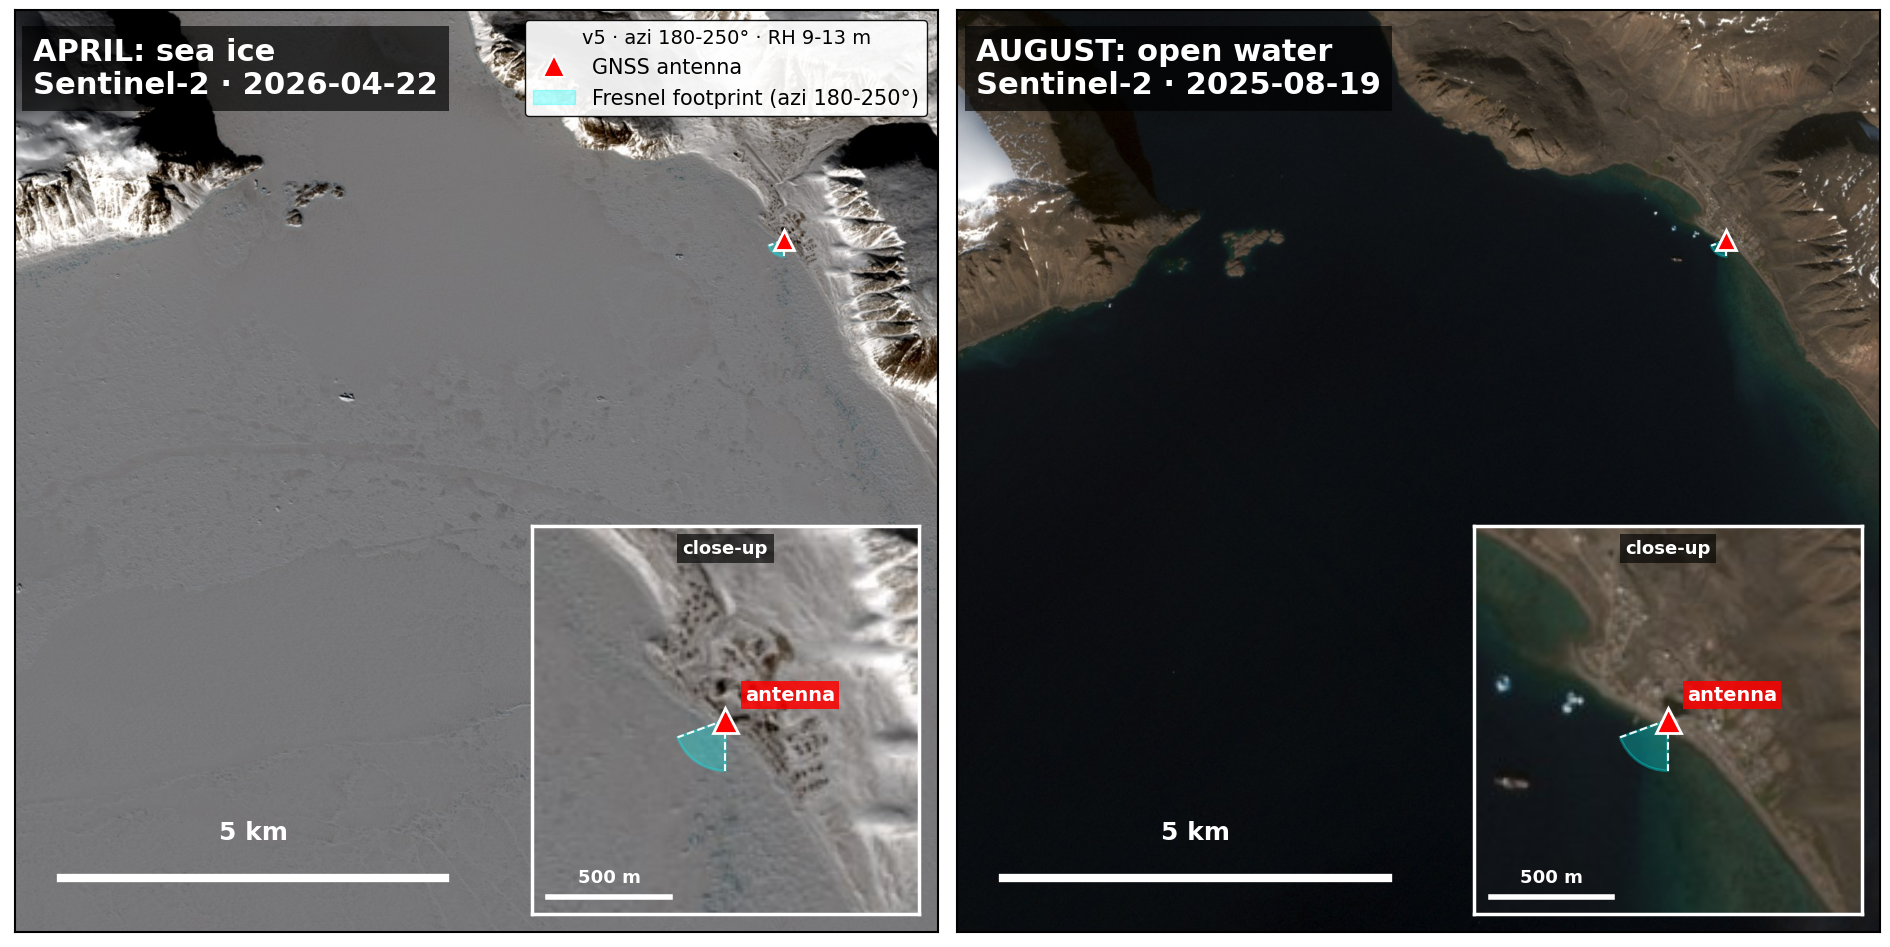

In [8]:
# ── 5b. Fresnel footprint on Sentinel-2 ──
from matplotlib.image import imread

scenes = json.loads((SAMPLE / 's2_scenes.json').read_text())

def fresnel(rh, eps_deg, lam=LAMBDA):
    "Semi-axes and specular distance of the first Fresnel zone."
    e = np.deg2rad(eps_deg)
    b = np.sqrt(lam * rh / np.sin(e))
    return b / np.sin(e), b, rh / np.tan(e)

a_far,  _, d_far  = fresnel(RHLIMS[1], ELVLIMS[0])    # far corner: high RH, low elevation
a_near, _, d_near = fresnel(RHLIMS[0], ELVLIMS[1])    # near corner: low RH, high elevation
R_OUTER = d_far + a_far
R_INNER = max(d_near - a_near, 0)
print(f'sensing footprint: {R_INNER:.0f} m to {R_OUTER:.0f} m from the antenna, '
      f'azimuth {AZILIMS[0]}-{AZILIMS[1]} deg')

def draw_overlays(ax, aE, aN, marker_size=14, antenna_label=False):
    # Wedge angles are measured from east counter-clockwise; azimuth is from north clockwise.
    ax.add_patch(Wedge((aE, aN), R_OUTER, 90 - AZILIMS[1], 90 - AZILIMS[0],
                       facecolor='cyan', alpha=0.30, edgecolor='cyan', lw=2.0))
    ax.add_patch(Wedge((aE, aN), R_INNER, 90 - AZILIMS[1], 90 - AZILIMS[0],
                       facecolor='none', edgecolor='cyan', lw=1.0, linestyle=':'))
    for az in AZILIMS:
        ax.plot([aE, aE + R_OUTER * np.sin(np.deg2rad(az))],
                [aN, aN + R_OUTER * np.cos(np.deg2rad(az))], 'w--', lw=1.5, alpha=0.95)
    ax.plot(aE, aN, marker='^', markersize=marker_size, color='red', mec='white', mew=2.0, zorder=12)
    if antenna_label:
        ax.annotate('antenna', (aE, aN), xytext=(14, 14), textcoords='offset points',
                    fontsize=14, color='white', fontweight='bold',
                    bbox=dict(fc='red', alpha=0.85, pad=3, edgecolor='none'))

# Both panels are drawn over the same window relative to the antenna so they render at
# the same size. The August scene is a UTM zone 16 tile and the antenna sits at the zone
# edge, so its imagery stops 2.3 km east of the antenna; that sets the eastern limit.
VIEW = dict(west=-10_000, east=2_000, south=-9_000, north=3_000)   # metres, 12 x 12 km
HALF_IN = 800                                                      # close-up half-window

fig, axes = plt.subplots(1, 2, figsize=(19, 10))
panels = [('april_seaice', 'APRIL: sea ice'), ('august_water', 'AUGUST: open water')]

for ax, (key, heading) in zip(axes, panels):
    sc  = scenes[key]
    img = imread(SAMPLE / f's2_{key}.jpg')
    left_E, right_E, bottom_N, top_N = sc['extent']
    aE, aN = sc['antenna_utm']

    ax.imshow(img, extent=(left_E, right_E, bottom_N, top_N), origin='upper',
              interpolation='bilinear', zorder=1)
    draw_overlays(ax, aE, aN)
    x0, x1 = aE + VIEW['west'],  aE + VIEW['east']
    y0, y1 = aN + VIEW['south'], aN + VIEW['north']
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)

    bx, by = x0 + 600, y0 + 700
    ax.plot([bx, bx + 5000], [by, by], 'w-', lw=6)
    ax.text(bx + 2500, by + 500, '5 km', color='white', ha='center',
            fontsize=18, fontweight='bold')
    ax.text(0.02, 0.97, f"{heading}\nSentinel-2 · {sc['date']}", transform=ax.transAxes,
            fontsize=22, fontweight='bold', color='white', ha='left', va='top',
            bbox=dict(facecolor='black', alpha=0.65, pad=8, edgecolor='none'))
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor('black'); sp.set_linewidth(1.5)

    # The footprint is ~210 m across, invisible at 12 km, so each panel gets a close-up.
    axins = ax.inset_axes([0.56, 0.02, 0.42, 0.42])
    axins.imshow(img, extent=(left_E, right_E, bottom_N, top_N), origin='upper',
                 interpolation='bilinear')
    draw_overlays(axins, aE, aN, marker_size=18, antenna_label=True)
    axins.set_xlim(aE - HALF_IN, aE + HALF_IN)
    axins.set_ylim(aN - HALF_IN, aN + HALF_IN)
    axins.set_xticks([]); axins.set_yticks([])
    for sp in axins.spines.values():
        sp.set_color('white'); sp.set_linewidth(2.5)
    axins.plot([aE - HALF_IN + 70, aE - HALF_IN + 570], [aN - HALF_IN + 70]*2, 'w-', lw=4)
    axins.text(aE - HALF_IN + 320, aN - HALF_IN + 130, '500 m', color='white',
               ha='center', fontsize=13, fontweight='bold')
    axins.text(0.5, 0.965, 'close-up', transform=axins.transAxes, fontsize=13,
               fontweight='bold', color='white', ha='center', va='top',
               bbox=dict(facecolor='black', alpha=0.65, pad=4, edgecolor='none'))

axes[0].legend(handles=[
    Line2D([0], [0], marker='^', linestyle='', markersize=16, markerfacecolor='red',
           markeredgecolor='white', markeredgewidth=1.5, label='GNSS antenna'),
    Patch(facecolor='cyan', alpha=0.30, edgecolor='cyan',
          label=f'Fresnel footprint (azi {AZILIMS[0]}-{AZILIMS[1]}°)'),
], loc='upper right', fontsize=15, facecolor='white', framealpha=0.92, edgecolor='black',
   title=f'v5 · azi {AZILIMS[0]}-{AZILIMS[1]}° · RH {RHLIMS[0]}-{RHLIMS[1]} m', title_fontsize=14)

plt.tight_layout()
fig.savefig(FIGS / 'gnssir_fresnel_seasonal.pdf', bbox_inches='tight',
            metadata={'CreationDate': None})
fig.savefig(FIGS / 'gnssir_fresnel_seasonal.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 6. A day of arcs, then a sea level series (steps 4 and 5)

### Step 4, all the arcs

`SNR.to_arcs` repeats steps 2 and 3 for every satellite, antenna and pass, writing one CSV row per arc into a
daily file. Reading them back, `arcs.py`'s `arcsqc` applies the config QC: `rhlims`, `ptnlim`, `clrlim`, and
`meanrhdifflim` to drop arcs far from the daily mean.

A single arc is noisy, but a day provides hundreds of independent estimates from different satellites and geometries. The tide is common to all of them, while the noise varies from arc to arc.

### Step 5, arcs to water level

`arcs2spline.py` fits a smooth curve through the day's heights, in **two passes** rather than one.

1. **First spline fit.** `spline.py`'s `Spline.fit` least-squares-fits cubic spline node values to the arc
   heights, with the **rhdot correction** active. The sea surface moves during an arc, which biases the
   retrieved height by an amount proportional to `tanededt` times the rate of change. Computing that needs a
   tide rate, which is why a first fit has to happen before the correction can be applied.
2. **Corrections.** Subtract the rhdot bias, then apply the **tropospheric correction** (`tropd.py`), which
   accounts for the atmosphere bending the signal and shifting the apparent elevation. Per-antenna offsets
   `ahgt` are added back, and QC runs again with `splinedifflim` rejecting arcs more than 1 m off the spline.
3. **Second spline fit** on the corrected arcs, rhdot now off since it is already applied.
4. **Spline QC.** Nodes whose fit error exceeds `maxerrlim` of 1 m are set to NaN, which is why the output
   has gaps.
5. **Datum flip.** `rh` measures downward from the antenna, so water level is `rh_datum - rh`. The spline is
   sampled every 5 minutes into the output CSV.

Both corrections matter here. With `RH` around 11 m and real tides, the moving-surface bias and atmospheric
bending are each large enough to shift the curve visibly.

672 arcs over three days, antennas [0, 1, 2, 3]
reflector height 9.01 to 12.77 m, mean 10.70 m
864 spline samples over the same three days, one every 5 minutes


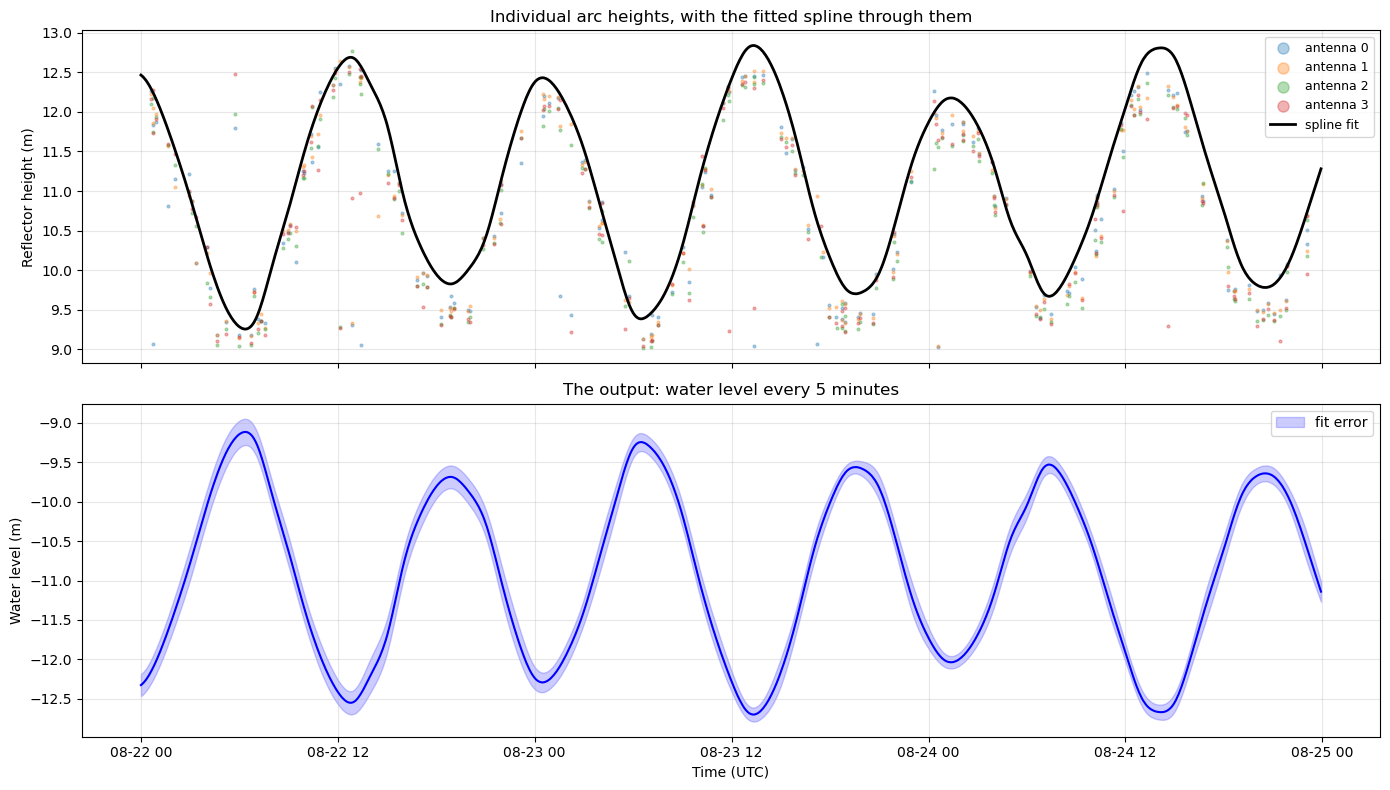

In [9]:
# ── 6. Three days of arcs with the spline through them, and the output ──
arc_frames = []
for day in ['240822', '240823', '240824']:
    d = pd.read_csv(SAMPLE / 'arcs_v5' / f'precipice_l1_{day}_24h.csv')
    d['datetime'] = d['t'].apply(gps_to_dt)
    arc_frames.append(d)
arcs3 = pd.concat(arc_frames, ignore_index=True)

sea3 = pd.read_csv(SAMPLE / 'spline_v5_sealevel_3day.csv', parse_dates=['datetime_utc'])
sea3 = sea3.dropna(subset=['water_level_m'])

print(f'{len(arcs3)} arcs over three days, '
      f'antennas {sorted(int(a) for a in arcs3["aid"].unique())}')
print(f'reflector height {arcs3["rh"].min():.2f} to {arcs3["rh"].max():.2f} m, '
      f'mean {arcs3["rh"].mean():.2f} m')
print(f'{len(sea3)} spline samples over the same three days, one every 5 minutes')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ant in sorted(arcs3['aid'].unique()):
    m = arcs3['aid'] == ant
    ax1.scatter(arcs3.loc[m, 'datetime'], arcs3.loc[m, 'rh'], s=4, alpha=0.35,
                color=ANT_COLORS.get(ant, 'gray'), label=f'antenna {ant}')
# Convert the spline back to reflector height to overlay it on the raw arcs.
ax1.plot(sea3['datetime_utc'], -sea3['water_level_m'] + np.mean(list(AHGT.values())),
         'k-', lw=2, label='spline fit', zorder=5)
ax1.set_ylabel('Reflector height (m)')
ax1.set_title('Individual arc heights, with the fitted spline through them')
ax1.legend(markerscale=4, loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(sea3['datetime_utc'], sea3['water_level_m'], 'b-', lw=1.5)
ax2.fill_between(sea3['datetime_utc'],
                 sea3['water_level_m'] - sea3['error_m'],
                 sea3['water_level_m'] + sea3['error_m'],
                 alpha=0.2, color='blue', label='fit error')
ax2.set_xlabel('Time (UTC)'); ax2.set_ylabel('Water level (m)')
ax2.set_title('The output: water level every 5 minutes')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGS / 'gnssir_step5_spline.png', dpi=150, bbox_inches='tight')
plt.show()

### Do the four antennas agree?

The site logs four antennas independently. They see the same water through the same processing pipeline, so their retrieved heights should track each other. Any disagreement gives us a measure of the per-antenna noise.

They are also mounted at slightly different heights. Antennas 0 and 1 sit 0.185 m above the reference point, while antennas 2 and 3 sit 0.095 m, a 0.090 m difference recorded when the instrument was built. That offset is not used during the arc retrieval. ahgt is only added back at the end of the spline stage. It is therefore a fixed hardware offset that the independent arc estimates should reproduce on their own.

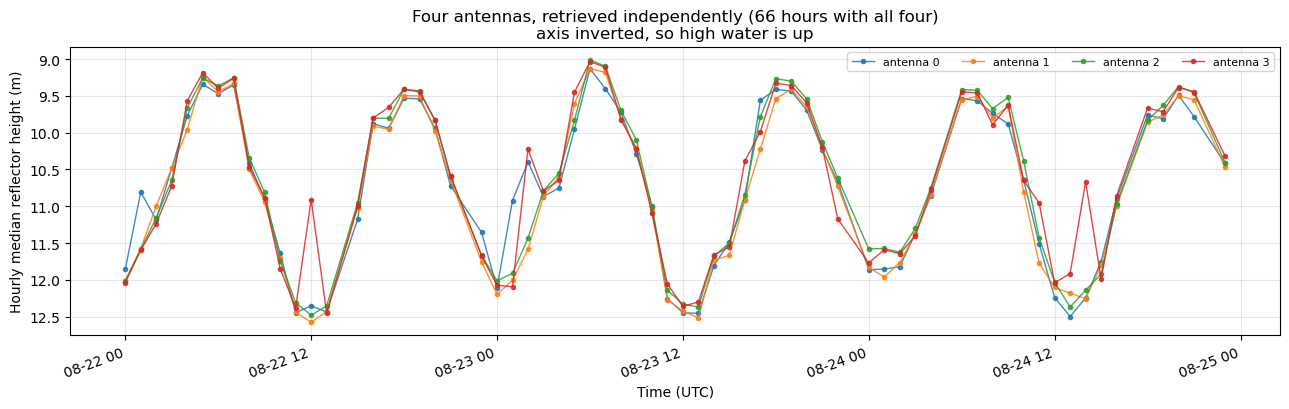

pairwise correlation of hourly median reflector height: 0.936 to 0.994
mounting offset, antennas 2 and 3 relative to 0 and 1:
  expected from build : -0.090 m
  observed in the arcs: -0.094 m   (difference 4 mm)


In [10]:
# ── 6b. Do the four antennas agree, and do they recover their mounting offset? ──
arcs3['hour'] = arcs3['datetime'].dt.floor('h')
hourly = arcs3.pivot_table(index='hour', columns='aid', values='rh', aggfunc='median').dropna()

means    = hourly.mean()
pair_hi  = (means[0] + means[1]) / 2      # antennas 0 and 1, mounted higher
pair_lo  = (means[2] + means[3]) / 2      # antennas 2 and 3
observed = pair_lo - pair_hi
expected = AHGT[2] - AHGT[0]

fig, ax1 = plt.subplots(figsize=(13, 4.2))

for aid in sorted(hourly.columns):
    ax1.plot(hourly.index, hourly[aid], 'o-', ms=3, lw=1,
             color=ANT_COLORS[aid], alpha=0.85, label=f'antenna {aid}')
ax1.set_ylabel('Hourly median reflector height (m)')
ax1.set_xlabel('Time (UTC)')
ax1.set_title(f'Four antennas, retrieved independently '
              f'({len(hourly)} hours with all four)\naxis inverted, so high water is up')
ax1.legend(fontsize=8, ncol=4)
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()
for lab in ax1.get_xticklabels():
    lab.set_rotation(20); lab.set_ha('right')

plt.tight_layout()
fig.savefig(FIGS / 'gnssir_antenna_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

corr  = hourly.corr()
pairs = [(i, j) for i in sorted(hourly.columns) for j in sorted(hourly.columns) if i < j]
print(f'pairwise correlation of hourly median reflector height: '
      f'{min(corr.loc[i, j] for i, j in pairs):.3f} to '
      f'{max(corr.loc[i, j] for i, j in pairs):.3f}')
print(f'mounting offset, antennas 2 and 3 relative to 0 and 1:')
print(f'  expected from build : {expected:+.3f} m')
print(f'  observed in the arcs: {observed:+.3f} m   '
      f'(difference {abs(observed - expected)*1000:.0f} mm)')

The four traces move together, with individual antennas scattering by a few centimetres, which gives the per-antenna retrieval noise over these three days. When the antennas are averaged within each mounted pair, the offset is recovered to within a few millimetres of the build value. Since the arc retrieval never uses that offset, recovering it independently is a useful check that the heights are tracking the real water surface rather than some other signal.

---
## 7. All the processing steps in one figure

One panel per step, using the arc and the days already loaded above.

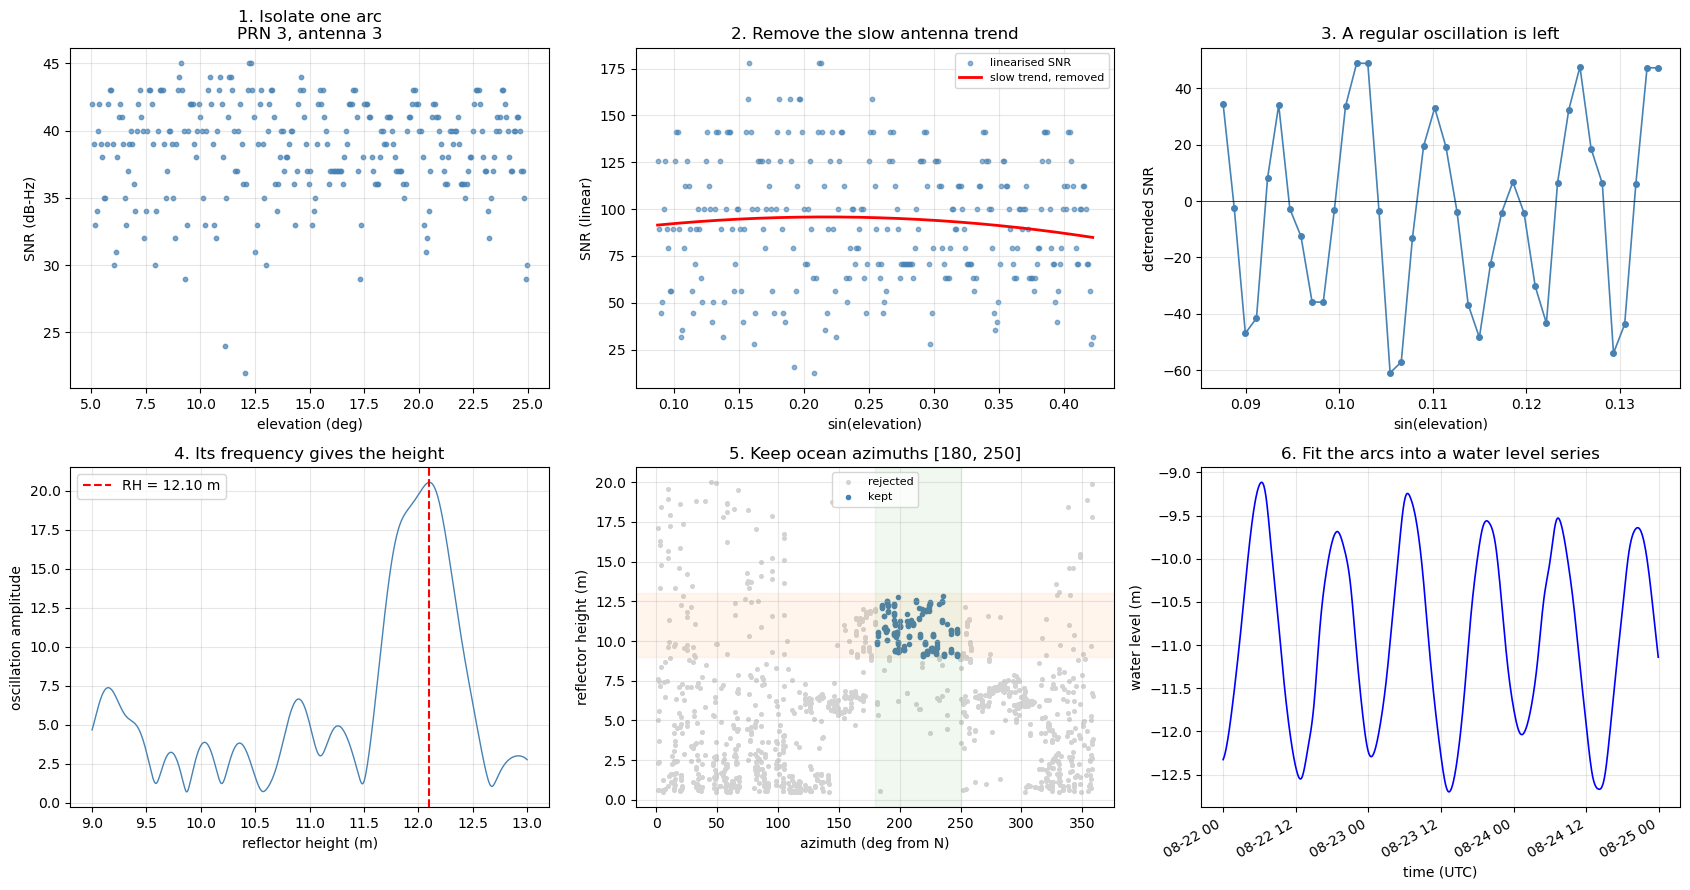

demonstrated on: 1 arc, then 672 arcs across 3 days


In [11]:
# ── 7. Summary figure ──
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

axes[0, 0].scatter(elv, snr_raw, s=10, c='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('elevation (deg)'); axes[0, 0].set_ylabel('SNR (dB-Hz)')
axes[0, 0].set_title(f'1. Isolate one arc\nPRN {prn}, antenna {aid}')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].scatter(sinelv, snr_lin, s=10, c='steelblue', alpha=0.6, label='linearised SNR')
axes[0, 1].plot(sinelv[order], trend[order], 'r-', lw=2, label='slow trend, removed')
axes[0, 1].set_xlabel('sin(elevation)'); axes[0, 1].set_ylabel('SNR (linear)')
axes[0, 1].set_title('2. Remove the slow antenna trend')
axes[0, 1].legend(fontsize=8); axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(sinelv[zm][zo], snr_dt[zm][zo], '-o', color='steelblue', lw=1.2, ms=4)
axes[0, 2].axhline(0, color='k', lw=0.5)
axes[0, 2].set_xlabel('sin(elevation)'); axes[0, 2].set_ylabel('detrended SNR')
axes[0, 2].set_title('3. A regular oscillation is left')
axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(rh_grid, pgram, color='steelblue', lw=1)
axes[1, 0].axvline(rh_est, color='red', ls='--', label=f'RH = {rh_est:.2f} m')
axes[1, 0].set_xlabel('reflector height (m)'); axes[1, 0].set_ylabel('oscillation amplitude')
axes[1, 0].set_title('4. Its frequency gives the height')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(allazi.loc[~keep, 'azi'], allazi.loc[~keep, 'rh'], s=7,
                   c='lightgray', label='rejected')
axes[1, 1].scatter(allazi.loc[keep, 'azi'], allazi.loc[keep, 'rh'], s=9,
                   c='steelblue', label='kept')
axes[1, 1].axvspan(*AZILIMS, color='tab:green', alpha=0.07)
axes[1, 1].axhspan(*RHLIMS,  color='tab:orange', alpha=0.07)
axes[1, 1].set_xlabel('azimuth (deg from N)'); axes[1, 1].set_ylabel('reflector height (m)')
axes[1, 1].set_title(f'5. Keep ocean azimuths {list(AZILIMS)}')
axes[1, 1].legend(fontsize=8); axes[1, 1].grid(alpha=0.3)

axes[1, 2].plot(sea3['datetime_utc'], sea3['water_level_m'], 'b-', lw=1.2)
axes[1, 2].set_xlabel('time (UTC)'); axes[1, 2].set_ylabel('water level (m)')
axes[1, 2].set_title('6. Fit the arcs into a water level series')
axes[1, 2].grid(alpha=0.3)
for lab in axes[1, 2].get_xticklabels():
    lab.set_rotation(30); lab.set_ha('right')

plt.tight_layout()
fig.savefig(FIGS / 'gnssir_pipeline_summary.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'demonstrated on: 1 arc, then {len(arcs3)} arcs across 3 days')

---
## 8. The full record

Everything above ran on one arc and three days. The production run uses the same three commands over the whole deployment: **August 2024 to October 2025, about 14 months**, across four antennas and a few hundred arcs per day, producing roughly 124,000 water level samples at 5-minute spacing.

> **The full series is not in this repo.** The PRECIPICE record is not public yet, so `sample_data/` carries three days, enough to run every step above. The figure below is included as an image so the result is visible; the code that draws it is left in place, and it will regenerate the figure for anyone working with the complete dataset.

Sea ice both dampens the tidal signal and scatters the reflected GNSS signal, which is why the middle of the record looks noisier than the cleaner open-water reflections at the start and end.

Gaps in the line are where spline QC set nodes to NaN, mostly stretches with too few arcs passing QC to constrain the fit.


### The vertical datum

The y-axis sits near -11 m, which is not a sea level. It is roughly how far the water is below the antenna.
`rh_datum` is 0 in the config, so the series is `0 - RH`: water level measured downward from the antenna
itself. As it stands only the variation is meaningful, not the absolute value.

To put the record on a real datum, the antenna's height above that datum has to be surveyed. Set `rh_datum`
to that height and rerun `arcs2splines`, or equivalently **add** it to every value here. Note the direction:
these numbers are already negative, so an antenna 11.5 m above chart datum would put the mean water level at
about +0.6 m, not at -22 m.

`RH` is estimated from the GNSS-IR measurements. What is missing is the tie to a vertical datum: the site coordinates here come from Google Earth, and we are waiting for the field team to provide precise GPS coordinates and the antenna height above the relevant vertical datum. Once we have that information, it can be used to define `rh_datum` and convert the record to absolute water level.

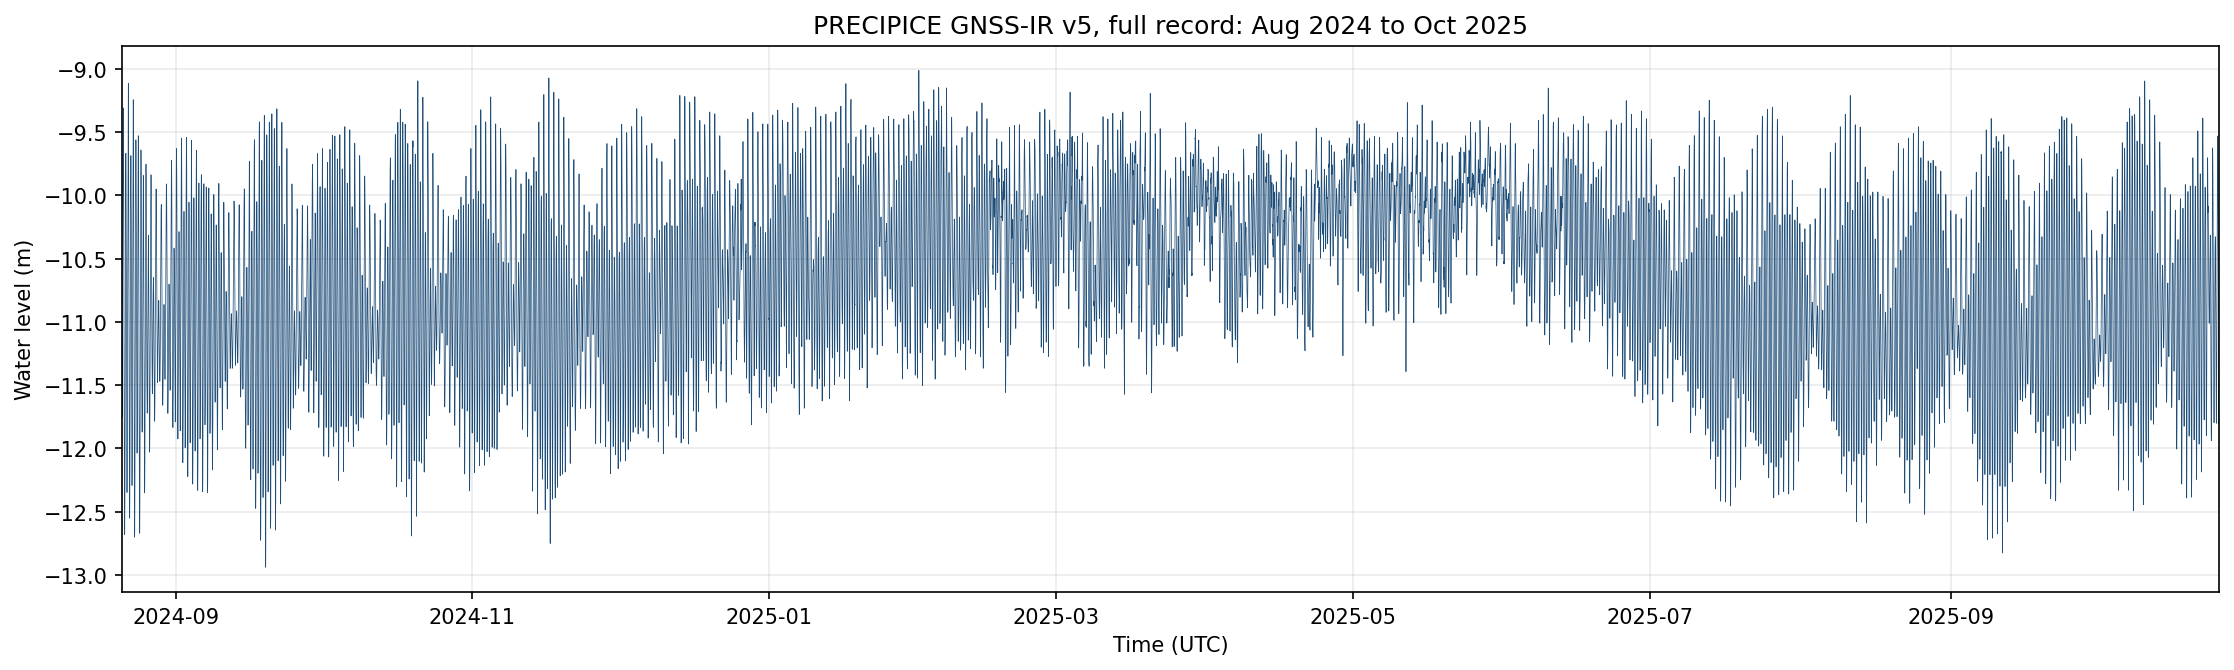

Full series not present, showing the committed figure.
The PRECIPICE record is not public yet; sample_data/ carries three days.


In [12]:
# ── 8. The whole v5 record ──
# The full series is not in the repo. If you have it, drop it in sample_data/ and this
# cell rebuilds the figure; otherwise it displays the committed one.
from IPython.display import Image, display

FULL_SEA = SAMPLE / 'spline_v5_sealevel.csv'
FIG_FULL = FIGS / 'gnssir_full_record.png'

if FULL_SEA.exists():
    sea = pd.read_csv(FULL_SEA, parse_dates=['datetime_utc']).dropna(subset=['water_level_m'])

    fig, ax = plt.subplots(figsize=(15, 4.6))
    ax.plot(sea['datetime_utc'], sea['water_level_m'], lw=0.35, color='#1f4e79')
    ax.set_ylabel('Water level (m)')
    ax.set_xlabel('Time (UTC)')
    ax.set_title(f'PRECIPICE GNSS-IR v5, full record: '
                 f'{sea["datetime_utc"].min():%b %Y} to {sea["datetime_utc"].max():%b %Y}')
    ax.set_xlim(sea['datetime_utc'].min(), sea['datetime_utc'].max())
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    fig.savefig(FIG_FULL, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'{len(sea):,} samples over '
          f'{(sea["datetime_utc"].max() - sea["datetime_utc"].min()).days} days')
else:
    display(Image(filename=str(FIG_FULL)))
    print('Full series not present, showing the committed figure.')
    print('The PRECIPICE record is not public yet; sample_data/ carries three days.')

---
## 9. Agreement with independent measurements

Everything so far is internal to the retrieval, apart from the antenna offsets. The real test is whether the record agrees with measurements that do not depend on the GNSS-IR retrieval.

Two independent references overlap the record in August 2025. An **in-situ pressure sensor** deployed at the site measures water level directly and has nothing to do with GNSS. The second is a **tide model** for Grise Fiord, taken from Arc5km2018, a 5 km Arctic barotropic model run through the Tide Model Driver.

All three are mean-centred before comparison, because each sits on a different datum.

The pressure sensor record was collected by
[David Didier's group at UQAR](https://www.uqar.ca/en/professeurs/didier-david/). The tide predictions come
from the Arc5km2018 solution, evaluated with the
[Tide Model Driver](https://github.com/chadagreene/Tide-Model-Driver), and were shared by Erica Lucas.

> **That data is not provided here**, so the two cells below display saved figures rather than recomputing.
> If you do have the files, drop them into `sample_data/private/` and the cells will run instead. That
> folder is checked at the top of each cell, and the `PRECIPICE_PRIVATE` environment variable overrides it
> if you keep the data elsewhere.

Over the 26-day overlap:

| | correlation | RMSE |
|---|---|---|
| GNSS-IR against pressure sensor | 0.976 | 0.174 m |
| GNSS-IR against tide model | 0.981 | 0.149 m |
| pressure sensor against tide model | 0.979 | 0.162 m |

GNSS-IR sits as close to each reference as the two references sit to each other, which is about as much as
this window can show.

The three do not agree everywhere. Around 12 August the pressure sensor records a peak roughly 0.8 m above
both the model and GNSS-IR, and there are smaller departures through the record. That is expected to some
degree: the model resolves tidal dynamics but carries no weather, while instruments have their own
artifacts. Sorting out which explains which departure is not attempted here and would need its own
analysis. Across the window as a whole the three stay closely aligned.

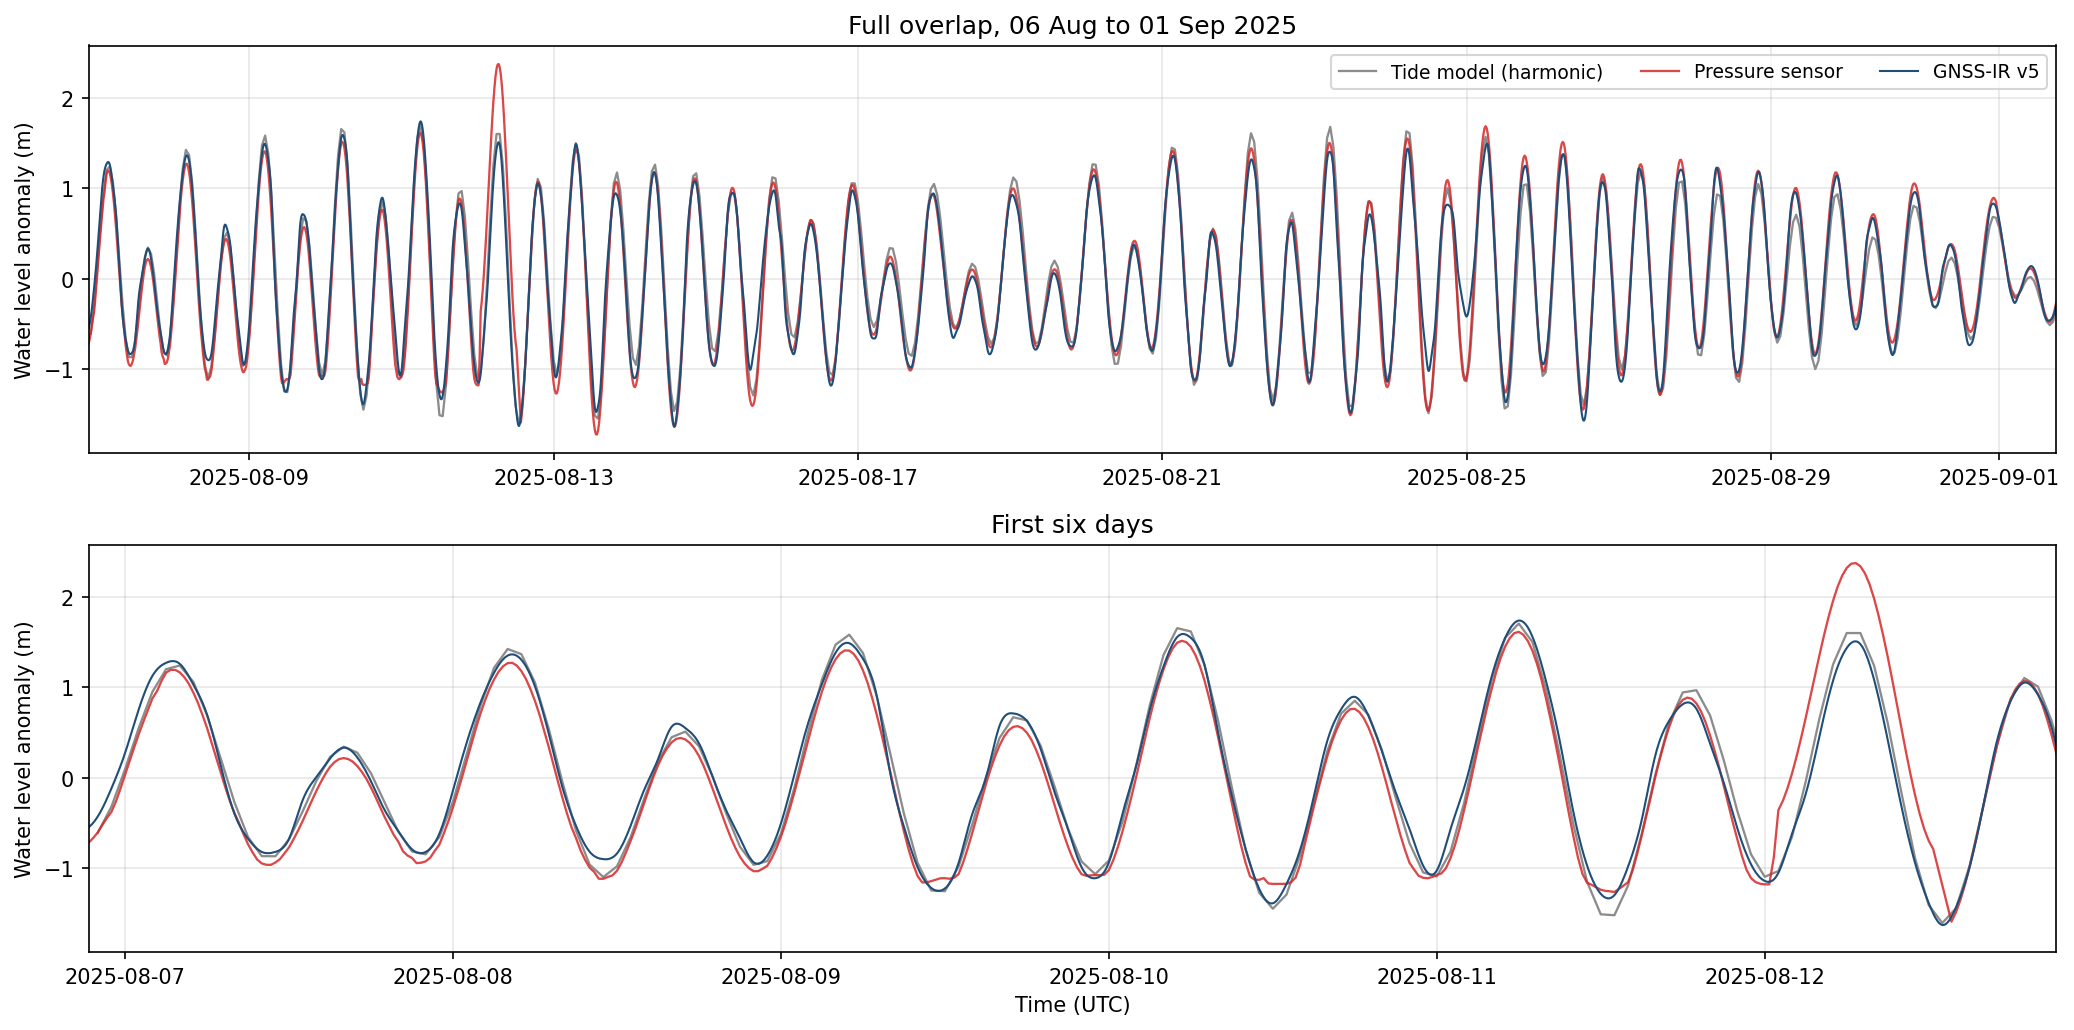

Reference data not provided here, showing the committed figure.


In [13]:
# ── 9a. GNSS-IR against a pressure sensor and a tide model ──
from IPython.display import Image, display

PRIVATE = Path(os.environ.get('PRECIPICE_PRIVATE', SAMPLE / 'private'))
FIG_CMP = FIGS / 'gnssir_vs_independent.png'
needed  = ['spline_v5_sealevel.csv', 'WL_GF_2025.mat', 'tide_model_2025.csv']

if all((PRIVATE / f).exists() for f in needed):
    from scipy.io import loadmat
    g = pd.read_csv(PRIVATE / needed[0], parse_dates=['datetime_utc']).dropna(subset=['water_level_m'])
    m = loadmat(str(PRIVATE / needed[1]))
    ps = pd.DataFrame({'time': pd.to_datetime(m['Time_UTC'].squeeze() - 719529, unit='D'),
                       'wl': m['WL_CGVD2013'].squeeze()}).dropna().sort_values('time')
    td = pd.read_csv(PRIVATE / needed[2])
    td.columns = td.columns.str.strip()
    td['time'] = pd.to_datetime(td['time'], format='%d-%b-%Y %H:%M:%S')

    W0, W1 = ps['time'].min(), ps['time'].max()
    gw = g[g['datetime_utc'].between(W0, W1)].sort_values('datetime_utc')
    tw = td[td['time'].between(W0, W1)].sort_values('time')

    # Work in seconds since W0. The three sources parse to different datetime
    # resolutions, so a raw int64 cast would silently put them on different scales.
    sec = lambda x: (x - W0).dt.total_seconds().values
    ga  = (gw['water_level_m'] - gw['water_level_m'].mean())
    pa  = (ps['wl'] - ps['wl'].mean())
    ta  = (tw['tide_height'] - tw['tide_height'].mean())

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
    for ax, (x0, x1), title in [(ax1, (W0, W1), f'Full overlap, {W0:%d %b} to {W1:%d %b %Y}'),
                                (ax2, (W0, W0 + pd.Timedelta(days=6)), 'First six days')]:
        ax.plot(tw['time'], ta, color='0.55', lw=1.1, label='Tide model (harmonic)')
        ax.plot(ps['time'], pa, color='tab:red', lw=1.1, alpha=0.85, label='Pressure sensor')
        ax.plot(gw['datetime_utc'], ga, color='#1f4e79', lw=1.0, label='GNSS-IR v5')
        ax.set_xlim(x0, x1); ax.set_ylabel('Water level anomaly (m)')
        ax.set_title(title); ax.grid(alpha=0.3)
    ax1.legend(ncol=3, loc='upper right', fontsize=9)
    ax2.set_xlabel('Time (UTC)')
    plt.tight_layout(); fig.savefig(FIG_CMP, dpi=150, bbox_inches='tight'); plt.show()

    gi = np.interp(sec(ps['time']), sec(gw['datetime_utc']), ga.values)
    ti = np.interp(sec(ps['time']), sec(tw['time']), ta.values)
    for lbl, u, v in [('GNSS-IR vs pressure sensor', gi, pa.values),
                      ('GNSS-IR vs tide model',      gi, ti),
                      ('pressure sensor vs tide',    pa.values, ti)]:
        u, v = u - u.mean(), v - v.mean()
        print(f'{lbl:28s} r = {np.corrcoef(u, v)[0, 1]:.3f}   '
              f'RMSE = {np.sqrt(np.mean((u - v) ** 2)):.3f} m')
else:
    display(Image(filename=str(FIG_CMP)))
    print('Reference data not provided here, showing the committed figure.')

### The same three, seen as spectra

The overlay shows the series track each other in time. The same question can be asked of each series on its
own, with no reference to the others: which periods does it contain?

The peaks are labelled with the standard tidal constituents. M2 is the principal lunar semidiurnal tide at
12.42 h, driven by the Moon; S2 is the solar equivalent at exactly 12.00 h; N2 is a smaller lunar term at
12.66 h; K1 and O1 are the diurnal constituents near 24 h. Twenty-six days is long enough to separate M2
from S2, unlike the three-day case. If GNSS-IR recovers the same constituents at the same periods as the pressure sensor and the regional tide model, then three very different approaches — a reflected satellite signal, an in-situ pressure measurement, and a numerical model of tidal dynamics — are recovering the same tidal signal despite their very different sources of error.

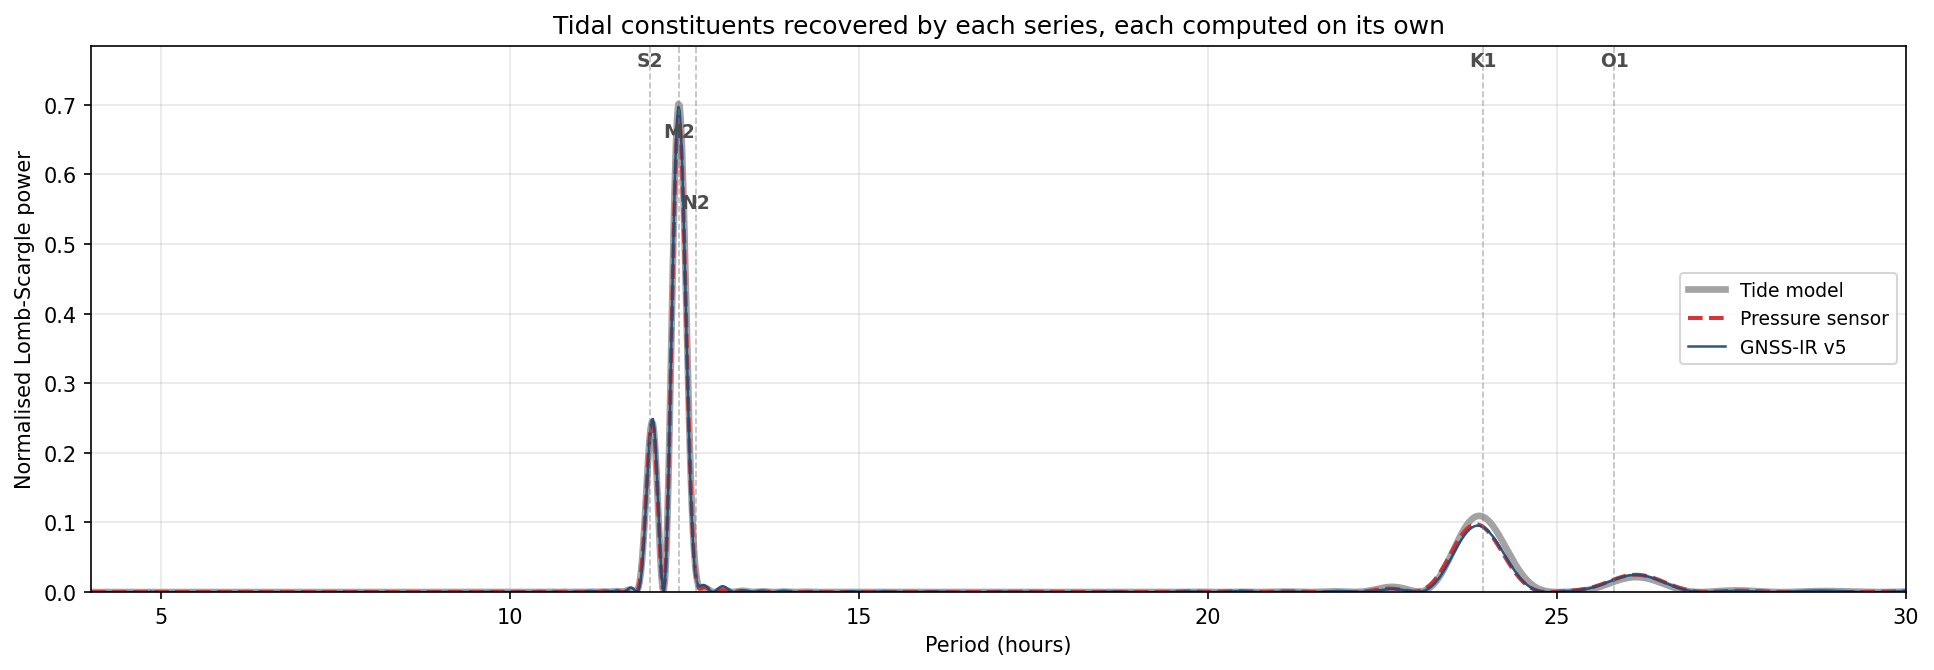

Reference data not provided here, showing the committed figure.


In [14]:
# ── 9b. Tidal constituents in each series, computed independently ──
from scipy.signal import lombscargle

FIG_SPEC = FIGS / 'gnssir_spectra_comparison.png'
CONSTITUENTS = {'S2': 12.0000, 'M2': 12.4206, 'N2': 12.6583, 'K1': 23.9345, 'O1': 25.8193}
LABEL_Y      = {'S2': 0.99, 'M2': 0.86, 'N2': 0.73, 'K1': 0.99, 'O1': 0.99}

if all((PRIVATE / f).exists() for f in needed):
    periods_h = np.linspace(4, 30, 1500)
    omega = 2 * np.pi / (periods_h * 3600.0)
    # The three curves land on top of each other, so vary width and style to keep all
    # three visible; that overlap is the result.
    power = {
        'Tide model':      (lombscargle(sec(tw['time']), ta.values, omega, normalize=True),
                            '0.62', 3.2, '-'),
        'Pressure sensor': (lombscargle(sec(ps['time']), pa.values, omega, normalize=True),
                            'tab:red', 1.9, '--'),
        'GNSS-IR v5':      (lombscargle(sec(gw['datetime_utc']), ga.values, omega, normalize=True),
                            '#1f4e79', 1.2, '-'),
    }
    fig, ax = plt.subplots(figsize=(13, 4.6))
    for label, (pw, colour, lw, ls) in power.items():
        ax.plot(periods_h, pw, color=colour, lw=lw, ls=ls, alpha=0.95, label=label)
    ymax = max(pw.max() for pw, *_ in power.values()) * 1.12
    for name, T in CONSTITUENTS.items():
        ax.axvline(T, color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.text(T, ymax * LABEL_Y[name], name, ha='center', va='top',
                fontsize=9, fontweight='bold', color='0.3')
    ax.set_xlim(4, 30); ax.set_ylim(0, ymax)
    ax.set_xlabel('Period (hours)'); ax.set_ylabel('Normalised Lomb-Scargle power')
    ax.set_title('Tidal constituents recovered by each series, each computed on its own')
    ax.legend(loc='center right', fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); fig.savefig(FIG_SPEC, dpi=150, bbox_inches='tight'); plt.show()

    for label, (pw, *_rest) in power.items():
        print(f'{label:16s} dominant period {periods_h[np.argmax(pw)]:.3f} h')
else:
    display(Image(filename=str(FIG_SPEC)))
    print('Reference data not provided here, showing the committed figure.')

The three curves are almost indistinguishable, which is the result. All three peak at 12.412 h, and the
same secondary constituents appear in each.

---
## Notes

**Reproducing the full run.** Point `basedir` in `sample_data/precipice_v5_full.yaml` at a copy of the raw data
and run the three `gnssir` tasks in order. The sample data here is the output of exactly that, cut down to a
few days so the notebook stays small.

**Caveats**

- The site coordinate is a Google Earth estimate, not surveyed. It sets the Fresnel geometry in section 5,
  the tropospheric correction in step 5, and it is why the record has no absolute vertical datum.
- `rhlims` was tuned partly against independent in-situ water level observations, so agreement with those
  observations is not a fully independent test of the configuration. Section 5's imagery check and the
  arc-height clustering do not depend on them.
- GPS time is converted without leap seconds. The offset is constant and well under the 5-minute output
  spacing, but it is not zero.
- The four antennas are treated as one instrument after `ahgt` offsets are added back. Any per-antenna
  vertical error goes straight into the combined series.

**Software and references**

- Processing software used here: [gnssir-rt-dev](https://github.com/Precipice-Sensors/gnssir-rt-dev),
  Dave Purnell's version for the custom PRECIPICE sensors
- His general implementation: [gnssir-rt](https://github.com/purnelldj/gnssir-rt)
- The reference toolkit and the place to read further:
  [gnssrefl](https://github.com/kristinemlarson/gnssrefl) by Kristine Larson, documented at
  [gnssrefl.readthedocs.io](https://gnssrefl.readthedocs.io/en/latest/)
- Background on the technique: [Roesler and Larson (2018)](https://doi.org/10.1007/s10291-018-0744-8)
- Imagery: Copernicus Sentinel-2, processed by ESA, via the
  [Copernicus Data Space](https://dataspace.copernicus.eu/)
- Pressure sensor record used in section 9: collected by
  [David Didier's group, UQAR](https://www.uqar.ca/en/professeurs/didier-david/)
- Tide predictions used in section 9: Arc5km2018, evaluated with the
  [Tide Model Driver](https://github.com/chadagreene/Tide-Model-Driver), shared by Erica Lucas

---
If you spot a mistake, please email **elena.savidge@gmail.com**